# **금융경제학**

- 금융경제학 (박기영 저, 시그마프레스) 교재에 사용된 데이터/모형/그래프 관련 작업을 수행하는 python notebook 파일임: https://github.com/FinancialEconomicsPython
- python 코드는 구글 코랩에서 사용하는 것을 기준으로 작성되었음.
- 데이터 파일이 필요한 경우 위치: https://drive.google.com/drive/folders/1sArqUZKnxWtkNtHe31iD1w-2xCVEhTj0?usp=share_link
- date: 2025/3/22, updated: 2026/2/24

## 인플레이션 joyplot

- 데이터 파일
    - CPI_items_weights2020.xlsx: 물가 통계 항목들, 가중치, 분류(근원 등). 가중치나 근원물가 항목 포함 여부 등 변화시만 업데이트 필요
    - CPI+core_SA.xlsx: 관리 제외 근원, 관리 제외 경직적, CPI, 근원에 대한 계절 조정치 (23.1까지 있으므로 이후 자료 분석하려면 업데이트 필요)
    - path_data 폴더에 저장해야 함
        
- 중요한 DataFrame
    - index_prices: CPI, 근원 등의 물가 수준을 모아 놓음
    - inf_table: index_prices에 있는 지표들의 yoy 증가율을 모아 놓음

# Project: 물가 관련
## 물가 관련 지표들 작성 자동화

- modified on 2022/6/29, created on 2022/3/12
- 작성자: 박기영
- ECOS API 부분: 민지연  

<div class="alert alert-block alert-info">
작업설명
</div>

# **금융경제학**

- 금융경제학 (박기영 저, 시그마프레스) 교재에 사용된 데이터/모형/그래프 관련 작업을 수행하는 python notebook 파일임: https://github.com/FinancialEconomicsPython
- python 코드는 구글 코랩에서 사용하는 것을 기준으로 작성되었음.
- 데이터 파일이 필요한 경우 위치: https://drive.google.com/drive/folders/1sArqUZKnxWtkNtHe31iD1w-2xCVEhTj0?usp=share_link
- date: 2025/3/22, updated: 2026/1/30

- CPI_items_weights2020.xlsx는 아래와 같은 형식임

![image.png](attachment:698cdbd1-cc88-44ab-8774-fa9cfbc77cb9.png)

- CPI+core_SA.xlsx는 아래와 같은 형식임

![image.png](attachment:ea4972e0-6ab6-4fe0-aac3-fa7ce4e93264.png)

In [1]:
# paths to specify: you can change for your own environment

path_figure = "/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/figures/"
path_file = '/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/data/'
path_data = '/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/data/'

In [71]:
# Where to save the figures
DIR = path_figure

def save_fig(fig_id, tight_layout=True):
    path = os.path.join(DIR, fig_id + ".png")
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format='png', dpi=600,
                bbox_inches='tight',      # ← 여백 자동 제거
                facecolor='white')        # ← 배경 흰색 보장

In [2]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import os
from datetime import date

import requests
import json
from urllib.request import urlopen

# 🔹 수정된 부분
from pandas import json_normalize

import seaborn as sns
from scipy import stats

%config InlineBackend.figure_format = 'retina'
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = '{:,.3f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 10

# koreanize_matplotlib 설치
# 1. 라이브러리 설치 (이미 되어 있다면 생략 가능)
!pip -q install koreanize-matplotlib

# 2. 임포트
import koreanize_matplotlib
import matplotlib.pyplot as plt

In [3]:
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=10)
mpl.rc('ytick', labelsize=12)

# to prevent (-) from being expressed as empty square
plt.rcParams['axes.unicode_minus'] = False

# Use seaborn style defaults and set the default figure size
#sns.set(rc={'figure.figsize':(15, 9)})
sns.set(rc={'figure.figsize':(9, 5)})

sns.set(style="darkgrid")

# Where to save the figures
DIR = path_figure

def save_fig(fig_id, tight_layout=True):
    path = os.path.join(DIR, fig_id + ".png")
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format='png', dpi=1000)

In [4]:
filepath = path_file

<div class="alert alert-block alert-info">
API, 표본기간 설정
    
- 아래 셀에서 분석 목적에 따라 수정할 필요
- 통상 key_api, date_start, date_end 만 수정 필요
</div>

In [5]:
# API key
key_api = 'X86F3N6MT6RRYXJ35P87'

# sample period
date_start = '2020-01'
date_end = '2025-12'

# 물가 데이터 불러오기
dates_list = pd.date_range(date_start, date_end, freq='MS').strftime("%Y-%m").tolist()

# months of interest for price growth distribution: dates_list[-3:]는 최근 3개월 의미
dates_dist = dates_list[-3:]

# 확산지수 등 경우  과거 몇 개월까지  볼 것인지
number_period = 18

# 품목성질별 기여도 관련
date_start_contri = dates_list[-number_period]
date_end_contri = dates_list[-1]
col_name_contri = '품목성질별'

# 물가 항목에서 수요가 차지하는 비중
date_start_demand = dates_list[-number_period]
date_end_demand = dates_list[-1]
col_name_demand = '근원'

# 물가항목별 기여도 분포에서 관심있는 달
date_choice = dates_dist

## 매핑 파일(신선/생활/근원 등) 불러오기

- 파일 불러오고
- 품목명, 가중치, 코어 여부 등 정리

In [6]:
df = pd.read_excel(path_data +'CPI_items_weights2020.xlsx', header=0)
df.head(3)

,품목명 (458개),품목성질별,가중치,식료품/에너지,신선식품,생활물가,농산물및석유류제외지수,식료품및에너지제외지수,기타특수분류,관리물가
0,쌀,농축수산물,5.500,비근원,NaN,○,○,NaN,NaN,관리제외
1,현미,농축수산물,0.500,비근원,NaN,NaN,○,NaN,NaN,관리제외
2,찹쌀,농축수산물,0.700,비근원,NaN,NaN,○,NaN,NaN,관리제외


In [7]:
# replacing NaN with False
df.fillna(False, inplace=True)

df.rename(columns={'품목명 (458개)':'품목명'},inplace=True)
df.rename(columns={'식료품/에너지':'근원'},inplace=True)
df.replace('근원',True,inplace=True)
df.replace('비근원',False,inplace=True)

df.replace('① ','신선어개',inplace=True)
df.replace('②','신선채소',inplace=True)
df.replace(' ③','신선과실',inplace=True)

df.replace('○',True,inplace=True)

df.replace('ⓣ','주거비',inplace=True)
df.replace('ⓤ','주거비제외서비스',inplace=True)
df.replace('ⓥ','에너지',inplace=True)

df.replace('관리제외',False,inplace=True)
df.replace('관리',True,inplace=True)

#df.drop(['식료품및에너지제외지수'],axis=1,inplace=True)

# tabulate variables
for col in df.columns[3:]:
    print(f'항목명: {col}')
    print(df[col].value_counts())
    print('\n')

df.set_index('품목명',inplace=True)
df.head(3)

항목명: 근원
근원
True     309
False    149
Name: count, dtype: int64


항목명: 신선식품
신선식품
False    403
신선채소      26
신선과실      18
신선어개      11
Name: count, dtype: int64


항목명: 생활물가
생활물가
False    314
True     144
Name: count, dtype: int64


항목명: 농산물및석유류제외지수
농산물및석유류제외지수
True     401
False     57
Name: count, dtype: int64


항목명: 식료품및에너지제외지수
식료품및에너지제외지수
True     309
False    149
Name: count, dtype: int64


항목명: 기타특수분류
기타특수분류
False       300
주거비제외서비스    142
에너지           9
주거비           7
Name: count, dtype: int64


항목명: 관리물가
관리물가
False    418
True      40
Name: count, dtype: int64




/tmp/ipython-input-2545581021.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('비근원',False,inplace=True)
/tmp/ipython-input-2545581021.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('○',True,inplace=True)
/tmp/ipython-input-2545581021.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

,품목성질별,가중치,근원,신선식품,생활물가,농산물및석유류제외지수,식료품및에너지제외지수,기타특수분류,관리물가
품목명,,,,,,,,,
쌀,농축수산물,5.500,False,False,True,True,False,False,False
현미,농축수산물,0.500,False,False,False,True,False,False,False
찹쌀,농축수산물,0.700,False,False,False,True,False,False,False


### 근원, 관리물가 등 항목

In [8]:
# 소비자물가 항목 리스트
list_all = df.index.tolist()

# 관리물가 항목
list_manage = df[df['관리물가']==True].index.tolist()

# 관리물가 제외 리스트
list_nomanage = df[df['관리물가']==False].index.tolist()

# 근원품목 리스트 (식료품 및 에너지 제외)
list_core = df[df['근원']==True].index.tolist()

# 비근원품목 리스트 (식료품 및 에너지)
list_noncore = df[df['근원']==False].index.tolist()

# 관리물가 제외 근원
list_core_nomanage = df[(df['근원']==True) & (df['관리물가']==False)].index.tolist()

# 생활물가
list_living = df[df['생활물가']==True].index.tolist()

# 농산물 및 석유류 제외
list_core_alter = df[df['농산물및석유류제외지수']==True].index.tolist()

print(f'소비자물가 항목수 = {len(list_all)}')
print(f'관리물가 항목수 = {len(list_manage)}')
print(f'관리물가 항목 제외 = {len(list_nomanage)}')
print(f'근원품목 = {len(list_core)}')
print(f'비근원품목 = {len(list_noncore)}')
print(f'관리물가 항목 제외 근원품목 = {len(list_core_nomanage)}')
print(f'생활물가 = {len(list_living)}')
print(f'농산물 및 석유류 제외 = {len(list_core_alter)}')

소비자물가 항목수 = 458
관리물가 항목수 = 40
관리물가 항목 제외 = 418
근원품목 = 309
비근원품목 = 149
관리물가 항목 제외 근원품목 = 272
생활물가 = 144
농산물 및 석유류 제외 = 401


## 물가 raw data 분석

다음 자료들 작성:
- 전년동기 대비 증가율
- 전월대비 증가율
- 전년동기 대비 물가상승률(inflation rate)

### ECOS 물가 통계 불러오기

<div class="alert alert-block alert-info">
물가 통계 불러오기 - API key 필요
</div>

In [9]:
# when this function does not work, check the expiration date of key_api
def import_cpi(datestart, key_api=key_api):
    '''
    to import cpi items with their price each month from ECOS
    input: date_start, key_api
    output: 품목명, 지수
    '''
    url_ecos2 = 'http://ecos.bok.or.kr/api/StatisticSearch/'+key_api+'/json/kr/1/10000/901Y009/M/'+datestart+'/'+datestart

    response = requests.get(url_ecos2)
    #print(response. status_code)

    result = urlopen(url_ecos2)
    data = result.read()
    data = json.loads(data)
    df = pd.DataFrame(data['StatisticSearch']['row'])
    df.sort_values(by = 'ITEM_CODE1')

    cpi_item = df.ITEM_CODE1.isin(['A01101', 'A01102', 'A01103', 'A01104', 'A01105', 'A01106', 'A01107', 'A01108', 'A01109', 'A01110', 'A01111', 'A01112', 'A01113', 'A01114', 'A01115', 'A01116', 'A01117', 'A01118', 'A01201', 'A01202', 'A01203', 'A01204', 'A01205', 'A01206', 'A01207', 'A01301', 'A01302', 'A01303', 'A01304', 'A01305', 'A01306', 'A01307', 'A01308', 'A01309', 'A01310', 'A01311', 'A01312', 'A01313', 'A01314', 'A01315', 'A01316', 'A01317', 'A01318', 'A01319', 'A01401', 'A01402', 'A01403', 'A01404', 'A01405', 'A01501', 'A01502', 'A01601', 'A01602', 'A01603', 'A01604', 'A01605', 'A01606', 'A01607', 'A01608', 'A01609', 'A01610', 'A01611', 'A01612', 'A01613', 'A01614', 'A01615', 'A01616', 'A01617', 'A01618', 'A01619', 'A01620', 'A01701', 'A01702', 'A01703', 'A01704', 'A01705', 'A01706', 'A01707', 'A01708', 'A01709', 'A01710', 'A01711', 'A01712', 'A01713', 'A01714', 'A01715', 'A01716', 'A01717', 'A01718', 'A01719', 'A01720', 'A01721', 'A01722', 'A01723', 'A01724', 'A01725', 'A01726', 'A01727', 'A01728', 'A01729', 'A01730', 'A01801', 'A01802', 'A01803', 'A01804', 'A01805', 'A01806', 'A01807', 'A01808', 'A01809', 'A01810', 'A01811', 'A01901', 'A01902', 'A01903', 'A01904', 'A01905', 'A01906', 'A01907', 'A01908', 'A01909', 'A01910', 'A01911', 'A01912', 'A01913', 'A01914', 'A01915', 'A01916', 'A01917', 'A01918', 'A01919', 'A01920', 'A02101', 'A02102', 'A02201', 'A02202', 'A02203', 'A02204', 'A02205', 'A02206', 'B01101', 'B01102', 'B01103', 'B01104', 'B01105', 'B01106', 'B02101', 'C01101', 'C01102', 'C01103', 'C01104', 'C01201', 'C01202', 'C01203', 'C01204', 'C01205', 'C01301', 'C01302', 'C01303', 'C01304', 'C01305', 'C01306', 'C01401', 'C01501', 'C01502', 'C01503', 'C01601', 'C01602', 'C02101', 'C02102', 'C02103', 'C02104', 'D01101', 'D01102', 'D03101', 'D03102', 'D04101', 'D04102', 'D04201', 'D04202', 'D04203', 'D05101', 'D05201', 'D05202', 'D05301', 'D05302', 'D05303', 'E01101', 'E01102', 'E01103', 'E01104', 'E01105', 'E01106', 'E01107', 'E01108', 'E02101', 'E02102', 'E03101', 'E03102', 'E03103', 'E03104', 'E03105', 'E03106', 'E03107', 'E03108', 'E03109', 'E03110', 'E03111', 'E03112', 'E03113', 'E03114', 'E03115', 'E03201', 'E03202', 'E04101', 'E04102', 'E04103', 'E04104', 'E04105', 'E04106', 'E04107', 'E04108', 'E05101', 'E05102', 'E05103', 'E06101', 'E06102', 'E06103', 'E06104', 'E06105', 'E06106', 'E06107', 'E06108', 'E06109', 'E06110', 'E06201', 'E06202', 'F01101', 'F01102', 'F01103', 'F01104', 'F01105', 'F01106', 'F01107', 'F01108', 'F01109', 'F01110', 'F01111', 'F01112', 'F01113', 'F01114', 'F01115', 'F01116', 'F01201', 'F01202', 'F01203', 'F01204', 'F01205', 'F01206', 'F01207', 'F01208', 'F01209', 'F01210', 'F02101', 'F02102', 'F02103', 'F02104', 'F02201', 'F02202', 'F03101', 'F03102', 'G01101', 'G01102', 'G01103', 'G01104', 'G01105', 'G01106', 'G01107', 'G01108', 'G02101', 'G02102', 'G02103', 'G02201', 'G02202', 'G02203', 'G02204', 'G02205', 'G02206', 'G02301', 'G02302', 'G02303', 'G02304', 'G02305', 'G02306', 'G03101', 'G03102', 'G03201', 'G03202', 'G03203', 'G03301', 'G03302', 'G03303', 'G03401', 'G03402', 'H01101', 'H02101', 'H03101', 'H03102', 'H03103', 'H03104', 'I01101', 'I01102', 'I01201', 'I01202', 'I01203', 'I01204', 'I01205', 'I02101', 'I02102', 'I03101', 'I03102', 'I03103', 'I03104', 'I03105', 'I03106', 'I03107', 'I04101', 'I04102', 'I04103', 'I04104', 'I04105', 'I04106', 'I04107', 'I04108', 'I04109', 'I04110', 'I04201', 'I04202', 'I04203', 'I04204', 'I04205', 'I04206', 'I04207', 'I04208', 'I05101', 'I05102', 'I05103', 'I05104', 'I05105', 'I05106', 'I05201', 'I05301', 'I05302', 'I05303', 'I05304', 'I06101', 'I06102', 'J01101', 'J03101', 'J03102', 'J03103', 'J03104', 'J03105', 'J04101', 'J04102', 'J04103', 'J04104', 'J04105', 'J04106', 'J04107', 'J04108', 'J04109', 'J04110', 'J04111', 'J04201', 'J04202', 'J04203', 'K01101', 'K01102', 'K01103', 'K01104', 'K01105', 'K01106', 'K01107', 'K01108', 'K01109', 'K01110', 'K01111', 'K01112', 'K01113', 'K01114', 'K01115', 'K01116', 'K01117', 'K01118', 'K01119', 'K01120', 'K01121', 'K01122', 'K01123', 'K01124', 'K01125', 'K01126', 'K01127', 'K01128', 'K01129', 'K01130', 'K01131', 'K01132', 'K01133', 'K01134', 'K01135', 'K01136', 'K01137', 'K01138', 'K01139', 'K02101', 'K02102', 'K02103', 'K02104', 'K02105', 'L01101', 'L01102', 'L01103', 'L01104', 'L01105', 'L01201', 'L01202', 'L01203', 'L01204', 'L01205', 'L01206', 'L01207', 'L01208', 'L01209', 'L01210', 'L01211', 'L01212', 'L01213', 'L02101', 'L02102', 'L02103', 'L02104', 'L02105', 'L02106', 'L02107', 'L02108', 'L03101', 'L03102', 'L03103', 'L03104', 'L03105', 'L03106', 'L03107', 'L03108', 'L03109', 'L03110', 'L03111'])
    df['cpi_item'] = cpi_item
    cpi_item = df['cpi_item'] == True
    cpi_item = df[cpi_item]
    cpi_item = cpi_item[['ITEM_NAME1','DATA_VALUE','TIME']]
    cpi_item.rename(columns={'ITEM_NAME1':'품목명', 'DATA_VALUE':cpi_item.TIME.iloc[0]},inplace=True)
    cpi_item.drop(['TIME'],axis=1, inplace=True)
    cpi_item.set_index('품목명',inplace=True)
    cpi_item = cpi_item.astype('float')

    return cpi_item

In [10]:
# import CPI item names and price index from ECOS
daterange = pd.date_range(date_start, date_end , freq='MS').strftime('%Y%m').tolist()

raw = pd.DataFrame()

for date_starting in daterange:
    cpi_item = import_cpi(date_starting, key_api=key_api)
    raw = pd.concat([raw,cpi_item],axis=1)

raw.head(2)

,202001,202002,202003,202004,202005,...,202508,202509,202510,202511,202512
품목명,,,,,,,,,,,
쌀,97.650,97.520,97.280,97.090,96.910,...,109.690,113.980,120.310,118.420,117.500
현미,100.480,99.430,99.940,100.230,99.810,...,129.390,131.810,133.990,132.440,130.290


In [11]:
# 원자료를 transponse하고 패널데이터 형태로 변환
raw_CPI = raw.transpose()
raw_CPI.reset_index(inplace=True)
raw_CPI.rename(columns={'index':'mdate'},inplace=True)

# 월별 날짜를 index로
yr_start = int(str(raw_CPI.mdate.iloc[0])[0:4])
mon_start = int(str(raw_CPI.mdate.iloc[0])[-2:])
yr_end = int(str(raw_CPI.mdate.iloc[-1])[0:4])
mon_end = int(str(raw_CPI.mdate.iloc[-1])[-2:])

raw_CPI['mdate'] =  pd.date_range(date(yr_start,mon_start,1),date(yr_end,mon_end,1),freq='MS')
raw_CPI.set_index('mdate',inplace=True)
raw_CPI = raw_CPI.asfreq('MS')
raw_CPI.head(3)

품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2020-01-01,97.650,100.480,100.930,103.490,102.980,...,100.000,100.000,99.910,100.000,99.680
2020-02-01,97.520,99.430,100.300,103.400,99.990,...,100.000,100.000,99.910,100.000,99.790
2020-03-01,97.280,99.940,100.580,102.820,99.870,...,100.000,100.000,99.910,100.000,99.750


In [12]:
raw_core = raw_CPI.loc[:,raw_CPI.columns.isin(list_core)]
raw_core.tail(3)

품목명,소주,과실주,맥주,막걸리,양주,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2025-10-01,108.390,102.780,115.840,123.190,118.480,...,92.280,98.670,101.140,116.100,109.270
2025-11-01,108.440,101.990,116.000,123.140,109.340,...,92.280,98.670,101.140,116.100,109.340
2025-12-01,108.520,98.830,115.790,123.140,107.890,...,92.280,98.670,101.140,116.100,109.350


### 전년 동월비 품목별 증가율(raw_growth_yoy)

In [13]:
# 전년동월비
raw_growth_yoy = raw_CPI.pct_change(12)*100
raw_growth_yoy.dropna(inplace=True)
raw_growth_yoy.tail(3)

품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2025-10-01,21.305,28.837,45.461,37.319,3.027,...,0.000,0.000,7.561,0.000,0.700
2025-11-01,18.562,25.798,34.225,33.085,2.655,...,0.000,0.000,7.561,0.000,0.765
2025-12-01,18.233,20.072,22.075,25.199,0.638,...,0.000,0.000,7.561,0.000,0.709


### 전월대비 품목별 증가율(raw_growth)

In [14]:
# 전월대비
raw_growth = raw_CPI.pct_change()*100
raw_growth.head(3)

품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
2020-02-01,-0.133,-1.045,-0.624,-0.087,-2.903,...,0.000,0.000,0.000,0.000,0.110
2020-03-01,-0.246,0.513,0.279,-0.561,-0.120,...,0.000,0.000,0.000,0.000,-0.040


### Joy Plot

https://towardsdatascience.com/creating-joy-plots-using-joypy-67327a15eb50

In [15]:
# 최신 seaborn과 joypy 재설치
!pip -q install -U joypy

In [16]:
#!pip install joypy

import joypy
import seaborn as sns

In [17]:
lags = 3
df_trimmed = pd.DataFrame()

raw_growth_lags = raw_CPI.pct_change(lags)*(12/lags)*100
raw_growth_lags = raw_growth_lags.dropna()

for i in range(0,len(raw_growth_lags)):
    df_trim = pd.DataFrame(raw_growth_lags.iloc[i])

    q_min = df_trim.quantile(q=0.13, interpolation='nearest')
    q_max = df_trim.quantile(q=0.88, interpolation='nearest')

    cond1 = (df_trim>=q_min).squeeze()
    cond2 = (df_trim<=q_max).squeeze()

    df_trim = df_trim.loc[cond1 & cond2]
    df_trim.columns = ['trimmed values']
    df_trim['mdate'] = i

    df_trimmed = pd.concat([df_trimmed, df_trim])

In [18]:
def generate_trimmed_inflation(type_inflation, lags, qrange):
    '''
    generate inflation rate after trimming
    type_inflatin: "CPI", "근원"
    lags = 12, 3, 6 (any reasonable integer)
    qrange = [0.13,0.88], or your choice like [0,1]
    '''
    df_trimmed = pd.DataFrame()
    qmin = qrange[0]
    qmax = qrange[-1]

    if type_inflation == "CPI":
        raw_growth_lags = raw_CPI.pct_change(lags) * (12 / lags) * 100
        raw_growth_lags = raw_growth_lags.dropna()
    else:
        raw_growth_lags = raw_core.pct_change(lags) * (12 / lags) * 100
        raw_growth_lags = raw_growth_lags.dropna()

    for i in range(0, len(raw_growth_lags)):
        df_trim = pd.DataFrame(raw_growth_lags.iloc[i])
        q_min = df_trim.quantile(q=qmin, interpolation='nearest')
        q_max = df_trim.quantile(q=qmax, interpolation='nearest')
        cond1 = (df_trim >= q_min).squeeze()
        cond2 = (df_trim <= q_max).squeeze()
        df_trim = df_trim.loc[cond1 & cond2]

        # 핵심 수정: chained assignment 대신 직접 대입
        mdate_value = df_trim.columns[0]
        df_trim['mdate'] = mdate_value.strftime('%Y-%m')
        df_trim.columns = ['trimmed values', 'mdate']
        df_trimmed = pd.concat([df_trimmed, df_trim])

    return df_trimmed

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import platform

# ── 한글 폰트 설정 ──────────────────────────────────────────
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        font_name = 'AppleGothic'
    else:  # Linux (Colab 등)
        korean_fonts = [f.name for f in fm.fontManager.ttflist
                        if 'Nanum' in f.name or 'nanum' in f.name]
        if korean_fonts:
            font_name = korean_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                           capture_output=True)
            fm._rebuild()   # ← 수정: __init__() 대신 _rebuild()
            font_name = 'NanumGothic'

    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()
# ────────────────────────────────────────────────────────────

/tmp/ipython-input-3521930.py:147: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-4199600262.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saving figure inf_joyplot


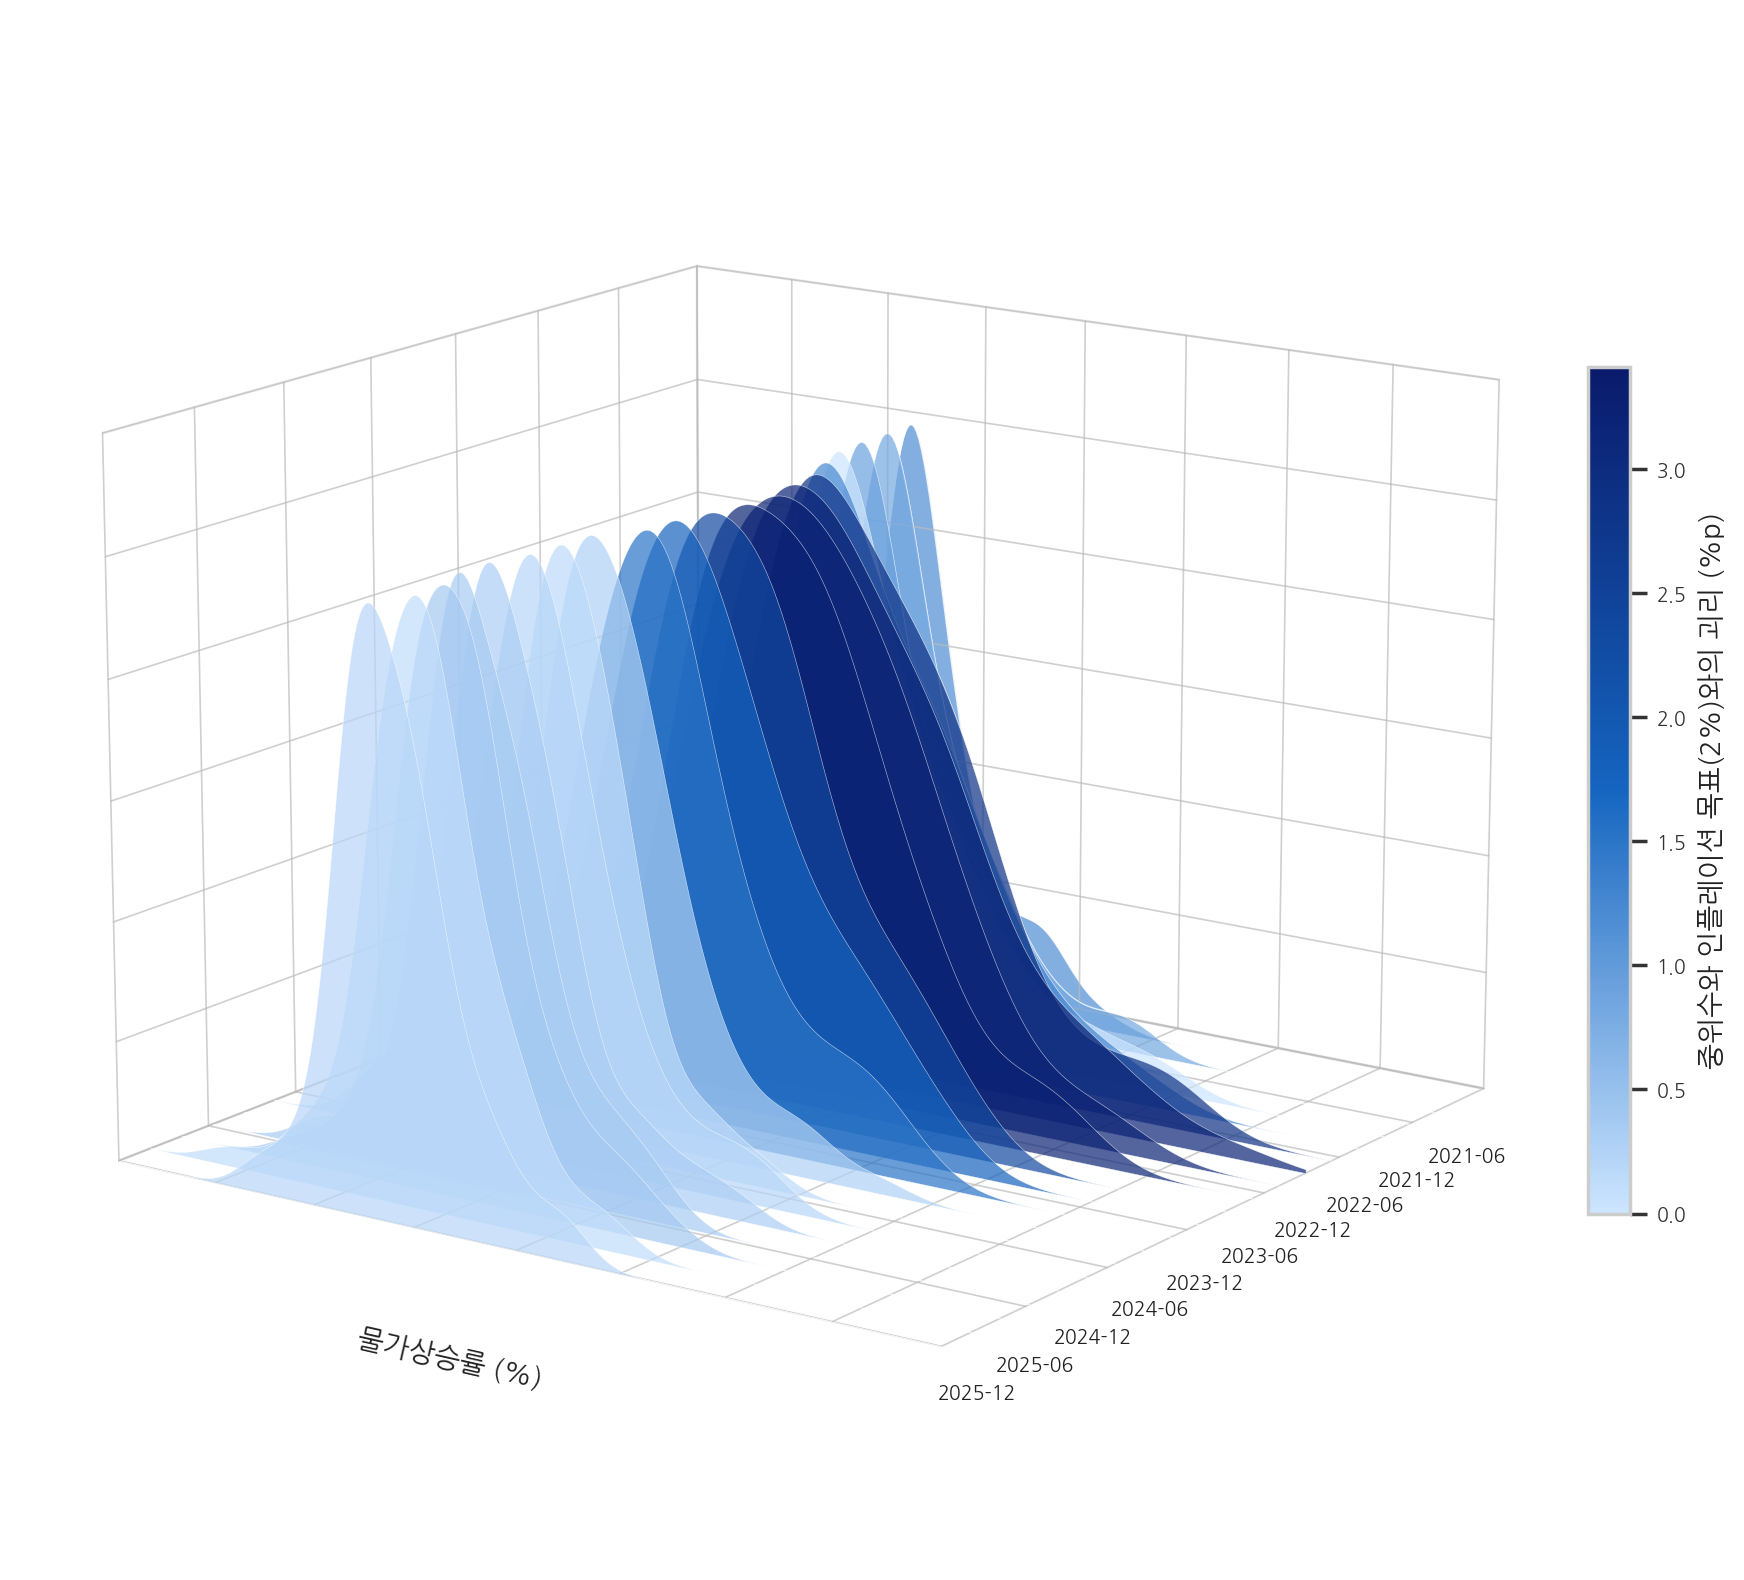

In [73]:
from matplotlib.colors import LinearSegmentedColormap

type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())

quarterly_only = True

plot_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]] \
             if quarterly_only else all_dates

#quarter_dates = [d for d in plot_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]
quarter_dates = [d for d in plot_dates if int(d.split('-')[1]) in [6, 12]]

all_vals = df_trimmed.loc[df_trimmed['mdate'].isin(plot_dates), 'trimmed values'].values
x_min = np.floor(all_vals.min()) - 2
x_max = np.ceil(all_vals.max()) + 2
x_grid = np.linspace(x_min, x_max, 300)

target = 2.0
z_max = 1.2   # ← z축 상한 (관찰 최대값 1.0의 1.2배)

medians = {}
for date in all_dates:
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) >= 2:
        medians[date] = np.median(vals)

deviations_abs = np.array([abs(medians[d] - target) for d in all_dates if d in medians])
dev_max = deviations_abs.max()

cmap_dev = LinearSegmentedColormap.from_list(
    'blue_mono', ['#cce5ff', '#1565C0', '#0a1a6b']
)

def dev_to_color(date, alpha=0.75):
    t = abs(medians[date] - target) / dev_max
    r, g, b, _ = cmap_dev(t)
    return (r, g, b, alpha)

fig = plt.figure(figsize=(18, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
n = len(plot_dates)

for idx, date in enumerate(plot_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    z = n - 1 - idx
    color = dev_to_color(date)

    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.7,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='white', linewidth=0.5, alpha=0.8)

ax.set_xlim([x_min, x_max])
ax.set_ylim([0, n])
ax.set_zlim([0, z_max])   # z_max 적용

# 수동 그리드 (z_max 기준으로 통일)
gc, gl, ga = '#bbbbbb', 0.6, 0.7
x_ticks = np.arange(x_min, x_max + 1, 5)
y_ticks = np.linspace(0, n, 8)
z_ticks = np.arange(0, z_max + 0.01, 0.2)   # z_max까지 그리드

for xv in x_ticks:
    ax.plot([xv, xv], [0, n], [0, 0], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([x_min, x_max], [yv, yv], [0, 0], color=gc, lw=gl, alpha=ga)
for xv in x_ticks:
    ax.plot([xv, xv], [n, n], [0, z_max], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([x_min, x_max], [n, n], [zv, zv], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([x_min, x_min], [yv, yv], [0, z_max], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([x_min, x_min], [0, n], [zv, zv], color=gc, lw=gl, alpha=ga)

ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#dddddd')
ax.yaxis.pane.set_edgecolor('#dddddd')
ax.zaxis.pane.set_edgecolor('#dddddd')

quarter_indices = [n - 1 - plot_dates.index(d) for d in quarter_dates if d in plot_dates]
ax.set_yticks(quarter_indices)
ax.set_yticklabels(
    [d for d in quarter_dates if d in plot_dates],
    fontsize=7, color='#222222'
)
ax.yaxis._axinfo['tick']['inward_factor'] = 0
ax.yaxis._axinfo['tick']['outward_factor'] = 0

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#222222', fontsize=10)
ax.set_ylabel('',              labelpad=12, color='#222222', fontsize=9)
ax.set_zlabel('',              labelpad=8,  color='#222222', fontsize=9)
ax.tick_params(axis='x', colors='#333333', labelsize=10)
ax.set_xticks([])
ax.tick_params(axis='z', colors='#333333', labelsize=8, labelleft=False, length=0)
ax.set_zticks([])

sm = plt.cm.ScalarMappable(cmap=cmap_dev, norm=plt.Normalize(vmin=0, vmax=dev_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01, aspect=20)
cbar.set_label('중위수와 인플레이션 목표(2%)와의 괴리 (%p)', fontsize=10, color='#222222')
cbar.ax.tick_params(labelsize=7, colors='#333333')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=15, azim=-55)

'''
freq_label = '분기별' if quarterly_only else '월별'
ax.set_title(
    f"물가 변화 분포, {type_inflation}, {freq_label} "
    f"({qrange[0]},{qrange[1]}) 트리밍, {lags}개월, 연율화\n"
    f"연한 파랑 = 목표(2%) 근접  |  진한 파랑 = 목표 이탈",
    color='#222222', fontsize=10, pad=15
)
'''

plt.tight_layout()
save_fig('inf_joyplot')
plt.show()

/tmp/ipython-input-906087725.py:144: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


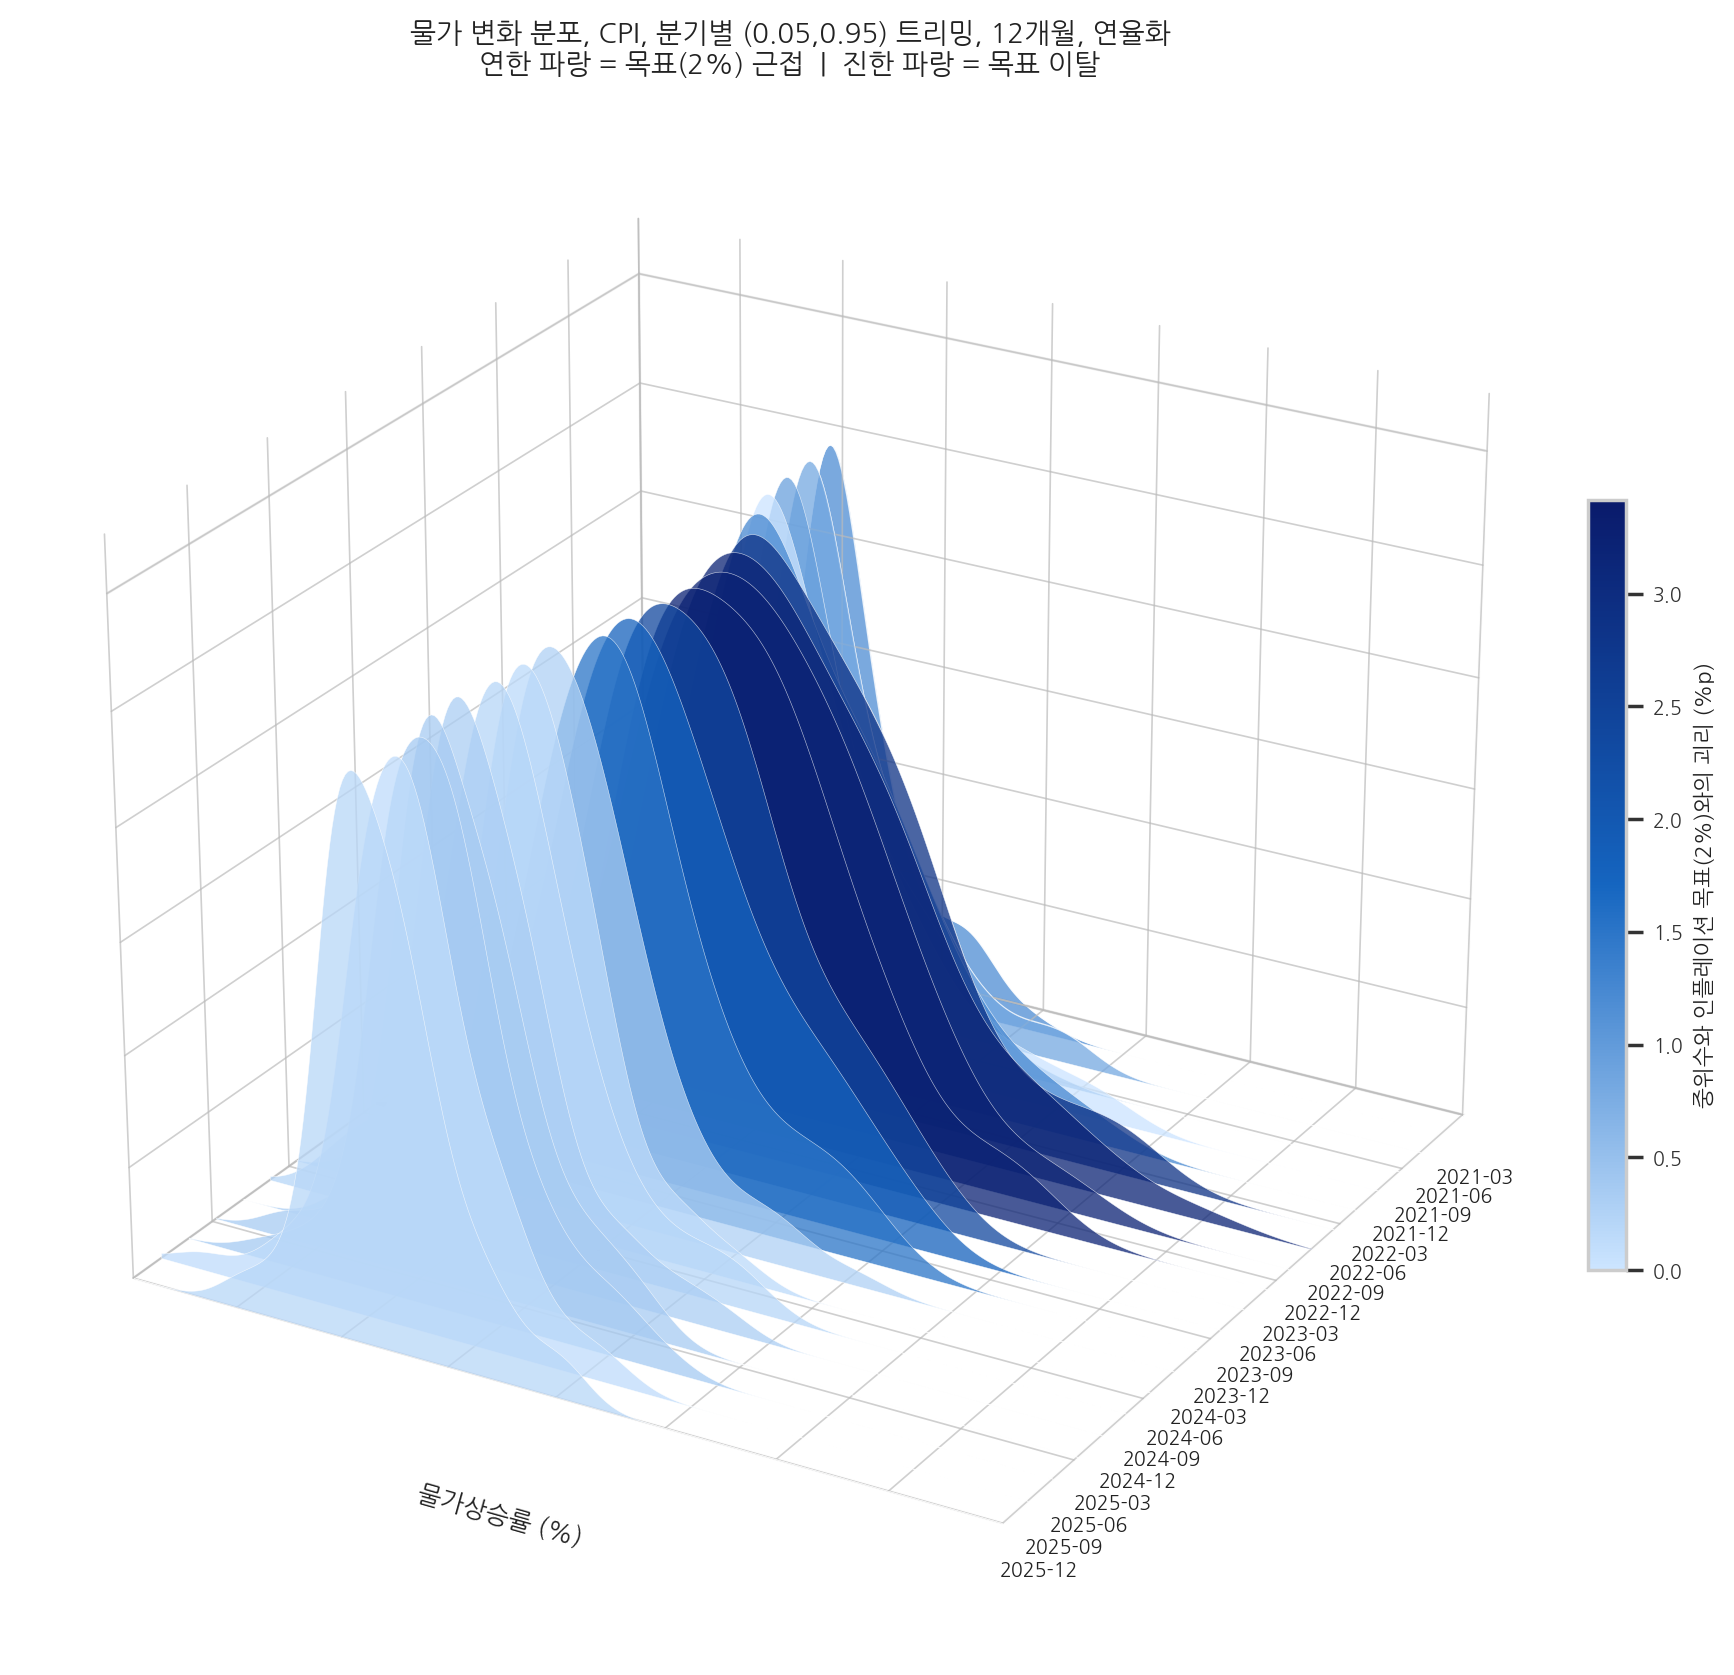

In [52]:
from matplotlib.colors import LinearSegmentedColormap

type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())

# ── 옵션: True면 3/6/9/12월만, False면 전체 ─────────────────
quarterly_only = True
# ────────────────────────────────────────────────────────────

plot_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]] \
             if quarterly_only else all_dates

quarter_dates = [d for d in plot_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]

x_grid = np.linspace(-10, 30, 300)
target = 2.0

# 중위수 계산 (전체 날짜 기준)
medians = {}
for date in all_dates:
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) >= 2:
        medians[date] = np.median(vals)

deviations_abs = np.array([abs(medians[d] - target) for d in all_dates if d in medians])
dev_max = deviations_abs.max()

# 연한 파랑 → 파랑 → 진한 파랑
cmap_dev = LinearSegmentedColormap.from_list('blue_mono', ['#cce5ff', '#1565C0', '#0a1a6b'])

# 연한 로열블루 → 로열블루 → 진한 로열블루
#cmap_dev = LinearSegmentedColormap.from_list('royal_blue', ['#e8eef9', '#4169E1', '#1a2f7a'])

def dev_to_color(date, alpha=0.75):
    t = abs(medians[date] - target) / dev_max
    r, g, b, _ = cmap_dev(t)
    return (r, g, b, alpha)

fig = plt.figure(figsize=(18, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
n = len(plot_dates)

for idx, date in enumerate(plot_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    z = n - 1 - idx
    color = dev_to_color(date)

    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.75,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='white', linewidth=0.5, alpha=0.8)

ax.set_xlim([-10, 30])
ax.set_ylim([0, n])
ax.set_zlim([0, 1.2])

# 수동 그리드
gc, gl, ga = '#bbbbbb', 0.6, 0.7
x_ticks = np.arange(-10, 31, 5)
y_ticks = np.linspace(0, n, 8)
z_ticks = np.arange(0, 1.31, 0.2)

for xv in x_ticks:
    ax.plot([xv, xv], [0, n], [0, 0], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([-10, 30], [yv, yv], [0, 0], color=gc, lw=gl, alpha=ga)
for xv in x_ticks:
    ax.plot([xv, xv], [n, n], [0, 1.3], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([-10, 30], [n, n], [zv, zv], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([-10, -10], [yv, yv], [0, 1.3], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([-10, -10], [0, n], [zv, zv], color=gc, lw=gl, alpha=ga)

ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#dddddd')
ax.yaxis.pane.set_edgecolor('#dddddd')
ax.zaxis.pane.set_edgecolor('#dddddd')

quarter_indices = [n - 1 - plot_dates.index(d) for d in quarter_dates if d in plot_dates]
ax.set_yticks(quarter_indices)
ax.set_yticklabels(
    [d for d in quarter_dates if d in plot_dates],
    fontsize=7, color='#222222'
)
ax.yaxis._axinfo['tick']['inward_factor'] = 0
ax.yaxis._axinfo['tick']['outward_factor'] = 0

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#222222', fontsize=9)
ax.set_ylabel('',              labelpad=12, color='#222222', fontsize=9)
ax.set_zlabel('',              labelpad=8,  color='#222222', fontsize=9)
ax.tick_params(axis='x', colors='#333333', labelsize=8)
ax.set_xticks([])   # 틱 위치 자체를 제거
ax.tick_params(axis='z', colors='#333333', labelsize=8,  labelleft=False, length=0)
ax.set_zticks([])   # 틱 위치 자체를 제거

sm = plt.cm.ScalarMappable(cmap=cmap_dev, norm=plt.Normalize(vmin=0, vmax=dev_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.01, aspect=20)
cbar.set_label('중위수와 인플레이션 목표(2%)와의 괴리 (%p)', fontsize=8, color='#222222')
cbar.ax.tick_params(labelsize=7, colors='#333333')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=25, azim=-60)

freq_label = '분기별' if quarterly_only else '월별'
ax.set_title(
    f"물가 변화 분포, {type_inflation}, {freq_label} "
    f"({qrange[0]},{qrange[1]}) 트리밍, {lags}개월, 연율화\n"
    f"연한 파랑 = 목표(2%) 근접  |  진한 파랑 = 목표 이탈",
    color='#222222', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

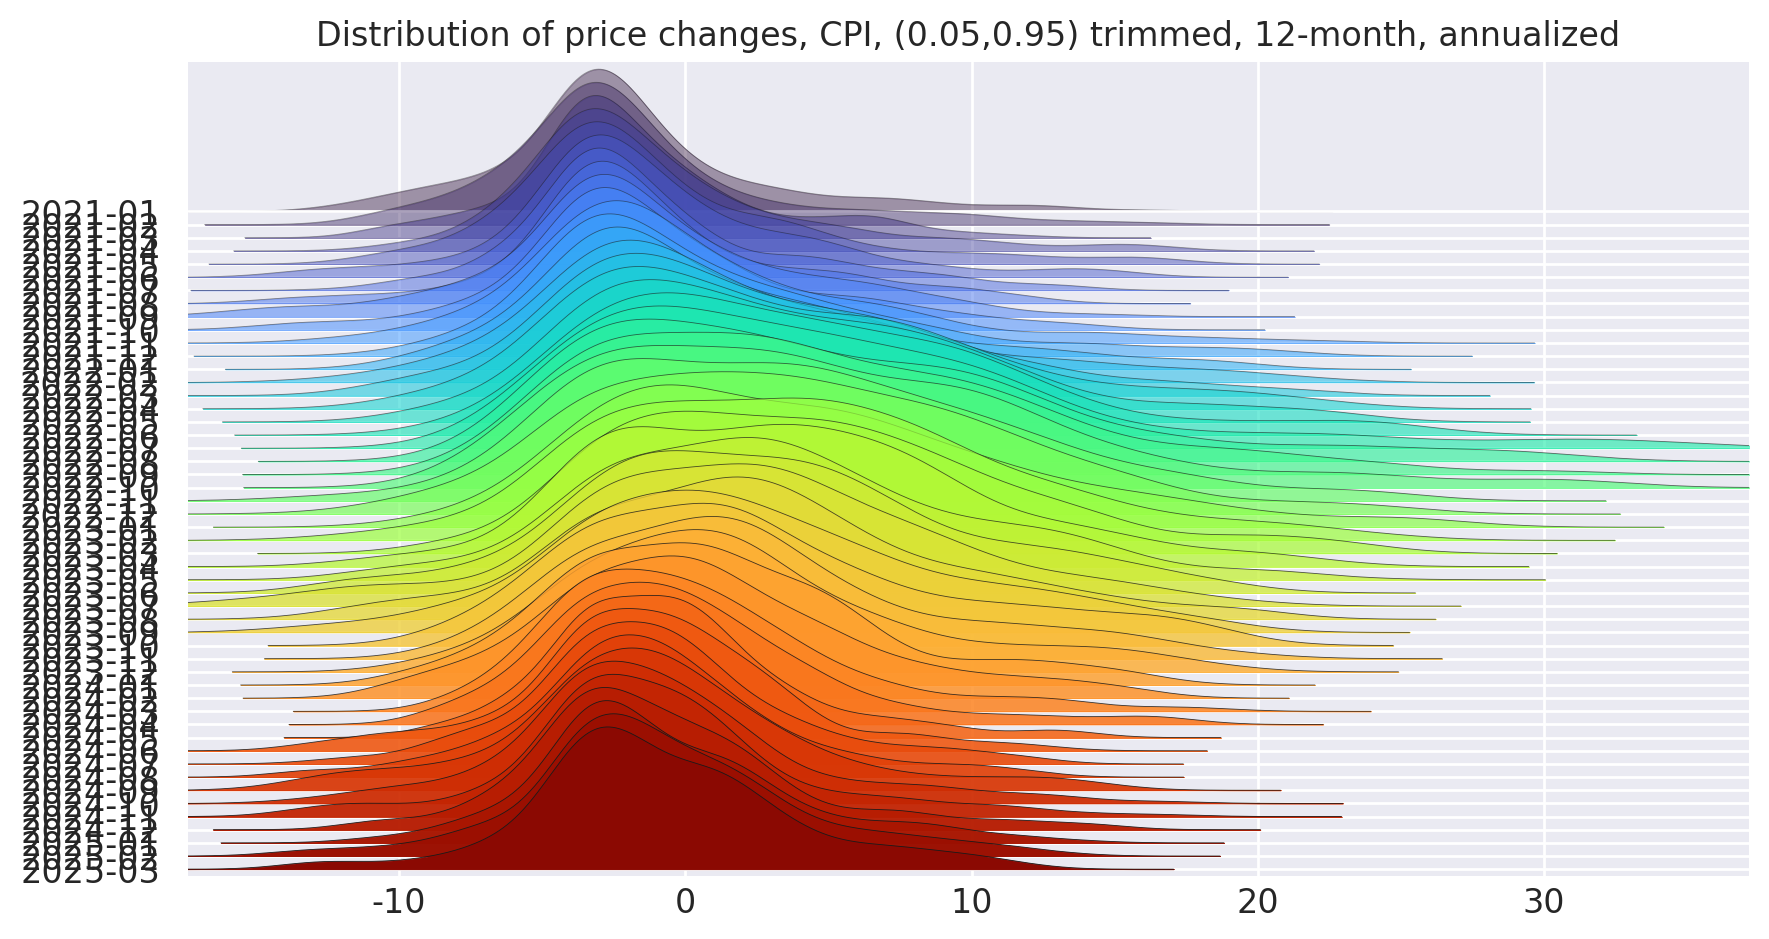

In [19]:
import matplotlib.cm as cm

type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(
    df_trimmed,
    by="mdate",
    range_style='own',
    ylim='own',
    fade=True,
    linewidth=0.3,
    colormap=cm.turbo,  # 또는 cm.viridis, cm.plasma, cm.turbo 등
    grid=True,
    title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
)

for a in axes[:-1]:
    a.set_xlim([-10, 30])

plt.show()

/tmp/ipython-input-2330591809.py:120: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


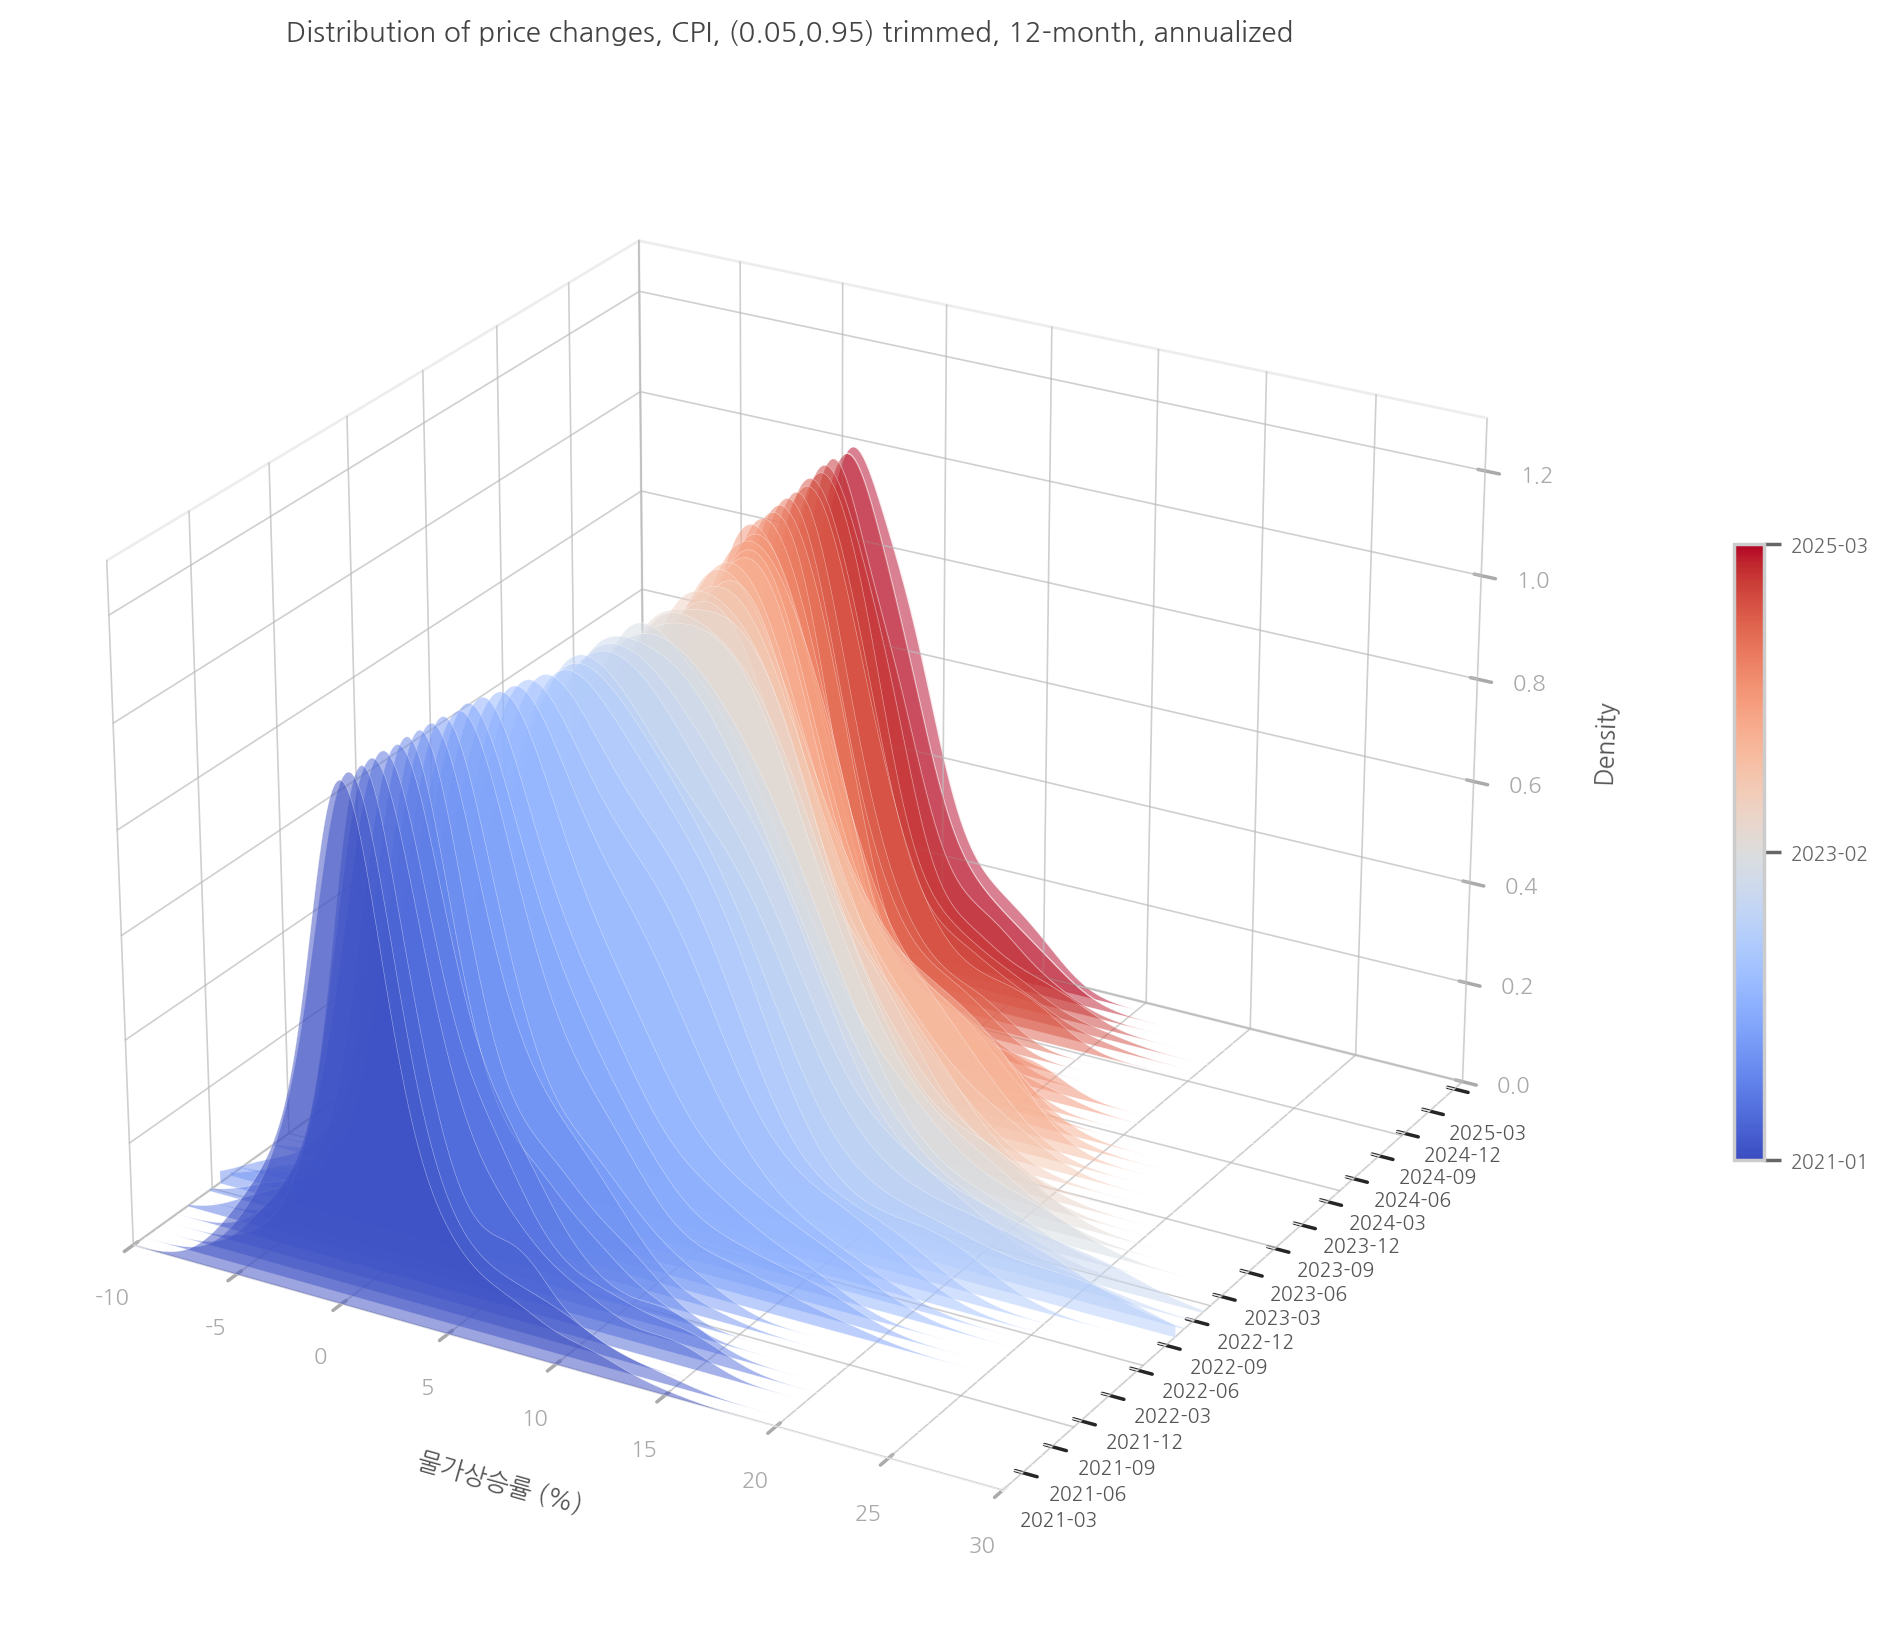

In [31]:
type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())
quarter_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]

x_grid = np.linspace(-10, 30, 300)

fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

n = len(all_dates)
cmap = cm.coolwarm

for idx, date in enumerate(all_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    z = idx
    color = cmap(idx / (n - 1))

    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.5,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='white', linewidth=0.5, alpha=0.8)

ax.set_xlim([-10, 30])
ax.set_ylim([0, n])
ax.set_zlim([0, 1.3])

# ── 수동 그리드 (ax.grid() 대신) ────────────────────────────
gc = '#bbbbbb'   # 그리드 색
gl = 0.6         # 선 굵기
ga = 0.7         # 투명도

x_ticks = np.arange(-10, 31, 5)
y_ticks = np.linspace(0, n, 8)
z_ticks = np.arange(0, 1.31, 0.2)

# 바닥면 (z=0): x선 + y선
for xv in x_ticks:
    ax.plot([xv, xv], [0, n], [0, 0], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([-10, 30], [yv, yv], [0, 0], color=gc, lw=gl, alpha=ga)

# 뒤쪽 세로면 (y=n): x선 + z선
for xv in x_ticks:
    ax.plot([xv, xv], [n, n], [0, 1.3], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([-10, 30], [n, n], [zv, zv], color=gc, lw=gl, alpha=ga)

# 옆면 (x=-10): y선 + z선
for yv in y_ticks:
    ax.plot([-10, -10], [yv, yv], [0, 1.3], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([-10, -10], [0, n], [zv, zv], color=gc, lw=gl, alpha=ga)
# ────────────────────────────────────────────────────────────

# 기본 grid 끄기, 패널 테두리만 유지
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#dddddd')
ax.yaxis.pane.set_edgecolor('#dddddd')
ax.zaxis.pane.set_edgecolor('#dddddd')

quarter_indices = [all_dates.index(d) for d in quarter_dates if d in all_dates]
ax.set_yticks(quarter_indices)
ax.set_yticklabels(
    [d for d in quarter_dates if d in all_dates],
    fontsize=7, color='#555555'
)

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#555555', fontsize=9)
ax.set_ylabel('',              labelpad=12, color='#555555', fontsize=9)
ax.set_zlabel('Density',       labelpad=8,  color='#555555', fontsize=9)

ax.tick_params(axis='x', colors='#aaaaaa', labelsize=8)
ax.tick_params(axis='z', colors='#aaaaaa', labelsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.08, aspect=20)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([all_dates[0], all_dates[n // 2], all_dates[-1]], fontsize=7)
cbar.ax.tick_params(colors='#666666')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=25, azim=-60)

ax.set_title(
    f"Distribution of price changes, {type_inflation}, "
    f"({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized",
    color='#444444', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

/tmp/ipython-input-52181774.py:100: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


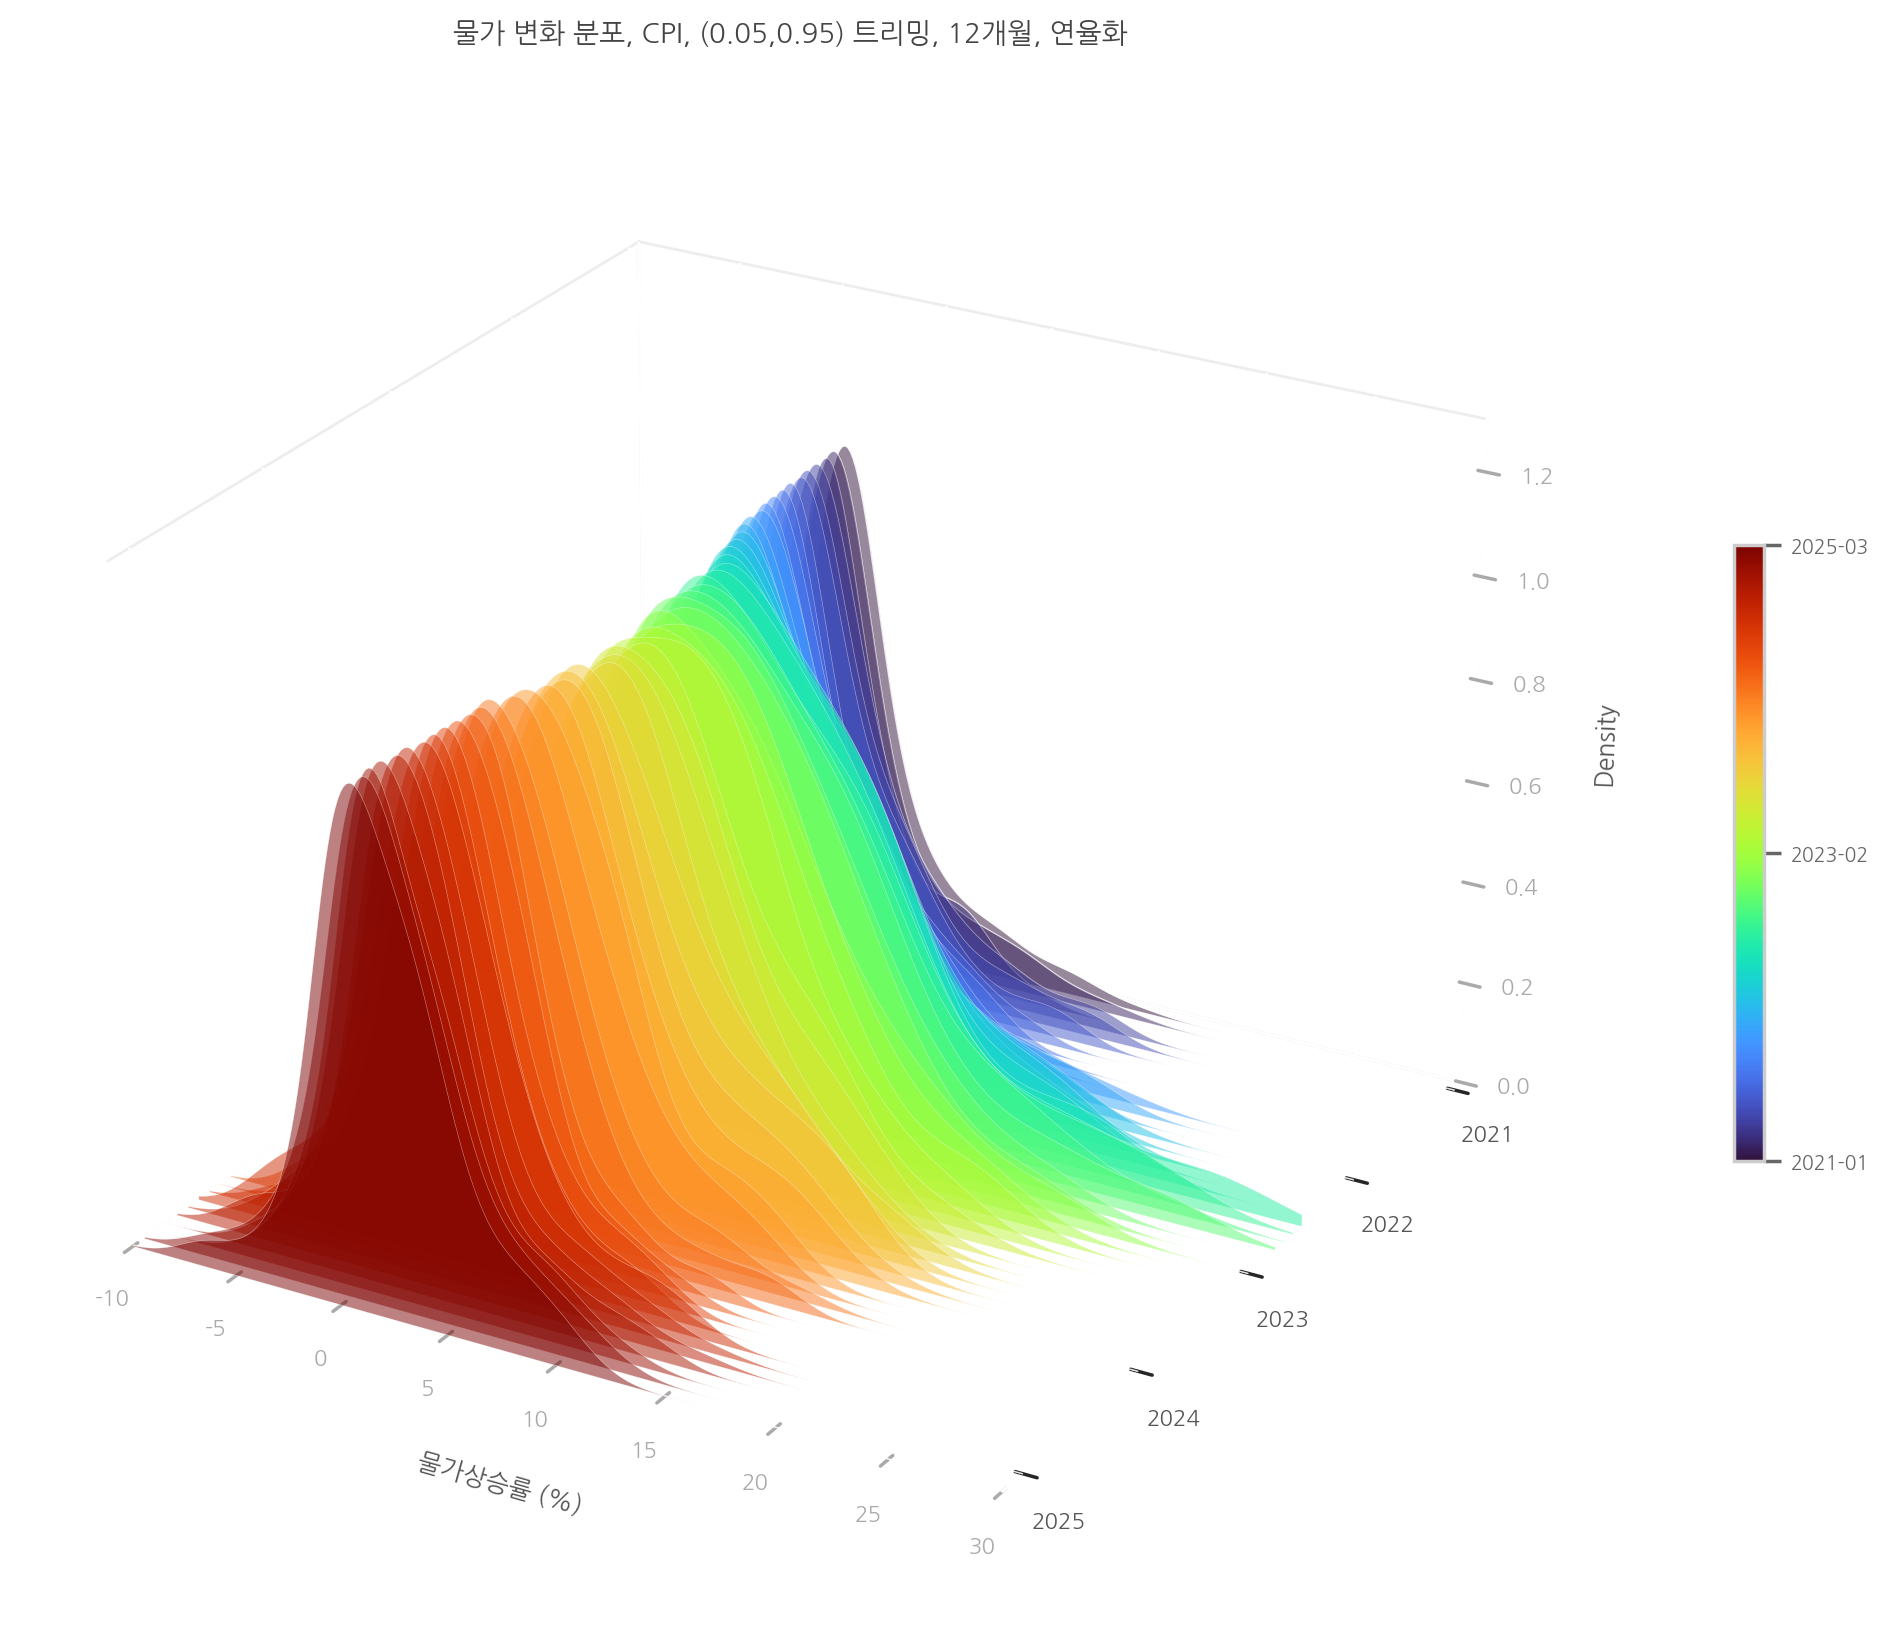

In [26]:
type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())

x_grid = np.linspace(-10, 30, 300)

fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

n = len(all_dates)
cmap = cm.turbo

for idx, date in enumerate(all_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    z = n - 1 - idx                  # 최근이 앞으로
    color = cmap(idx / (n - 1))      # 과거→최근 색상

    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.5,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='white', linewidth=0.5, alpha=0.8)

ax.set_xlim([-10, 30])
ax.set_ylim([0, n])
ax.set_zlim([0, 1.3])

# ── 그리드: 이전 코드 방식 유지 (핵심) ──────────────────────
ax.xaxis.pane.fill = True                        # fill=True여야 그리드가 패널에 표시됨
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True
ax.xaxis.pane.set_facecolor((1, 1, 1, 0.0))     # 투명하게 채우기
ax.yaxis.pane.set_facecolor((1, 1, 1, 0.0))
ax.zaxis.pane.set_facecolor((1, 1, 1, 0.0))
ax.xaxis.pane.set_edgecolor('#dddddd')
ax.yaxis.pane.set_edgecolor('#dddddd')
ax.zaxis.pane.set_edgecolor('#dddddd')
ax.grid(color='#cccccc', linewidth=0.5)          # 그리드 색·굵기
# ────────────────────────────────────────────────────────────

# 연도별 레이블
yearly_indices = []
yearly_labels  = []
for d in all_dates:
    if d.endswith('-01') or (d.endswith('-03') and
            not any(a.startswith(d[:4]) for a in all_dates if a.endswith('-01'))):
        yearly_indices.append(n - 1 - all_dates.index(d))
        yearly_labels.append(d[:4])

ax.set_yticks(yearly_indices)
ax.set_yticklabels(yearly_labels, fontsize=8, color='#555555')

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#555555', fontsize=9)
ax.set_ylabel('',               labelpad=12, color='#555555', fontsize=9)
ax.set_zlabel('Density',        labelpad=8,  color='#555555', fontsize=9)

ax.tick_params(axis='x', colors='#aaaaaa', labelsize=8)
ax.tick_params(axis='z', colors='#aaaaaa', labelsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.08, aspect=20)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([all_dates[0], all_dates[n // 2], all_dates[-1]], fontsize=7)
cbar.ax.tick_params(colors='#666666')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=25, azim=-60)

ax.set_title(
    f"물가 변화 분포, {type_inflation}, "
    f"({qrange[0]},{qrange[1]}) 트리밍, {lags}개월, 연율화",
    color='#444444', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3473011945.py:91: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


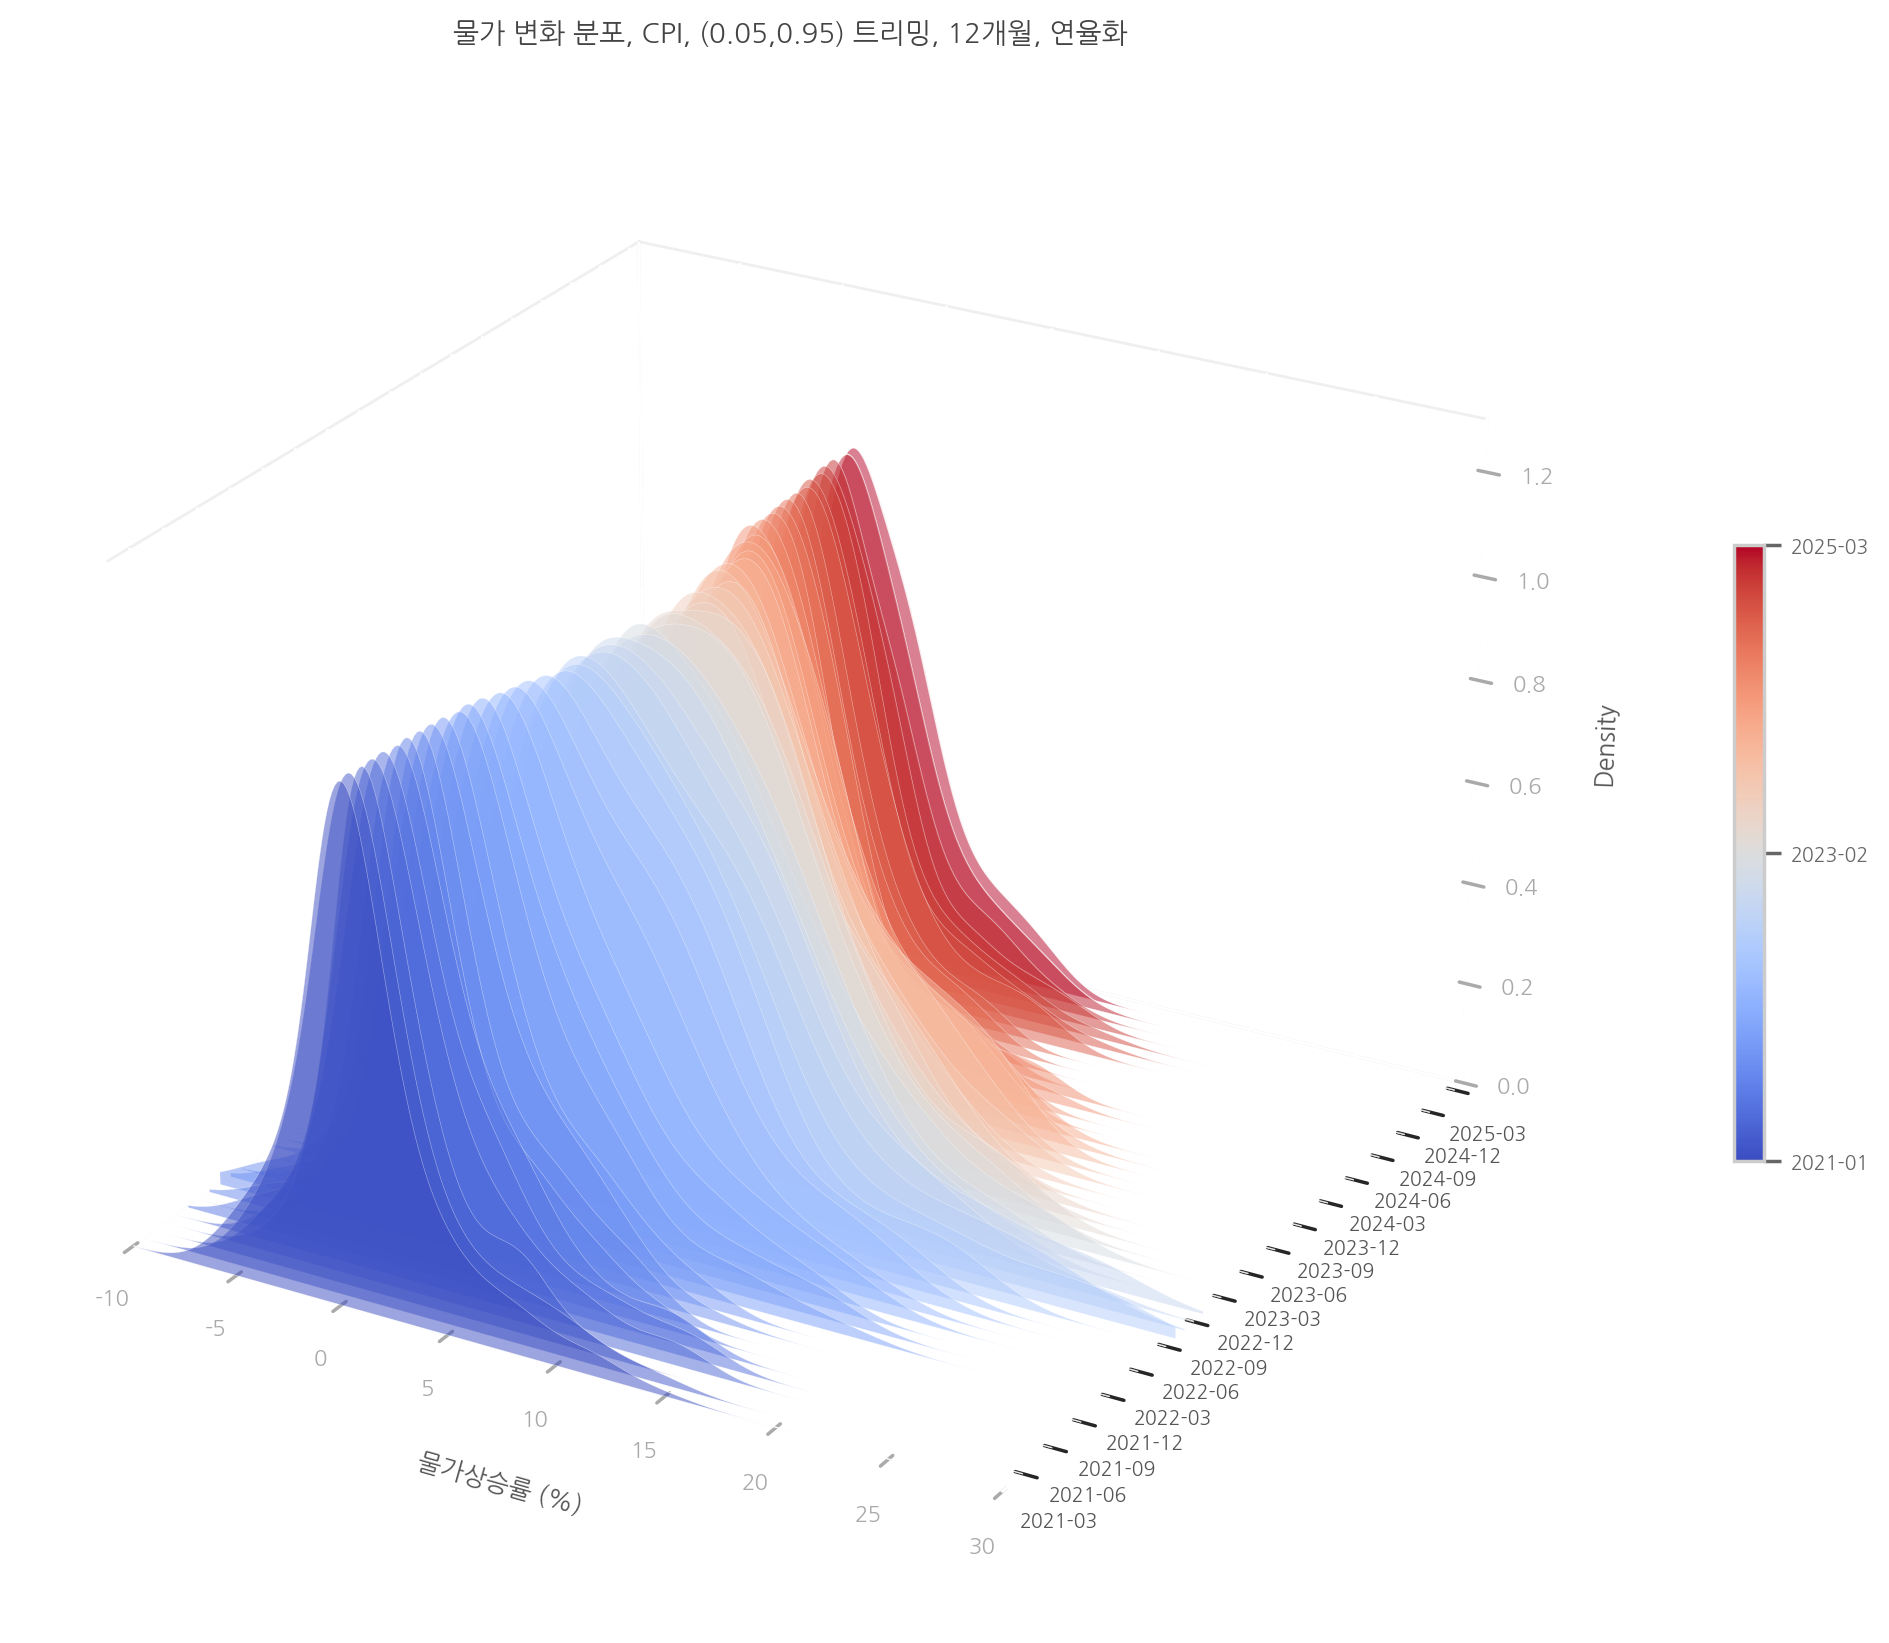

In [22]:

type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())
quarter_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]

x_grid = np.linspace(-10, 30, 300)

fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

n = len(all_dates)
cmap = cm.coolwarm

for idx, date in enumerate(all_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    z = idx
    color = cmap(idx / (n - 1))

    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.5,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='white', linewidth=0.5, alpha=0.8)

ax.set_xlim([-10, 30])
ax.set_ylim([0, n])
ax.set_zlim([0, 1.3])

quarter_indices = [all_dates.index(d) for d in quarter_dates if d in all_dates]
ax.set_yticks(quarter_indices)
ax.set_yticklabels(
    [d for d in quarter_dates if d in all_dates],
    fontsize=7, color='#555555'
)

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#555555', fontsize=9)
ax.set_ylabel('', labelpad=12, color='#555555', fontsize=9)
ax.set_zlabel('Density', labelpad=8, color='#555555', fontsize=9)

ax.tick_params(axis='x', colors='#aaaaaa', labelsize=8)
ax.tick_params(axis='z', colors='#aaaaaa', labelsize=8)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#e0e0e0')
ax.yaxis.pane.set_edgecolor('#e0e0e0')
ax.zaxis.pane.set_edgecolor('#e0e0e0')
ax.grid(color='#eeeeee', linewidth=0.4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.08, aspect=20)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([all_dates[0], all_dates[n // 2], all_dates[-1]], fontsize=7)
cbar.ax.tick_params(colors='#666666')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=25, azim=-60)

ax.set_title(
    f"물가 변화 분포, {type_inflation}, "
    f"({qrange[0]},{qrange[1]}) 트리밍, {lags}개월, 연율화",
    color='#444444', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3446547344.py:102: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


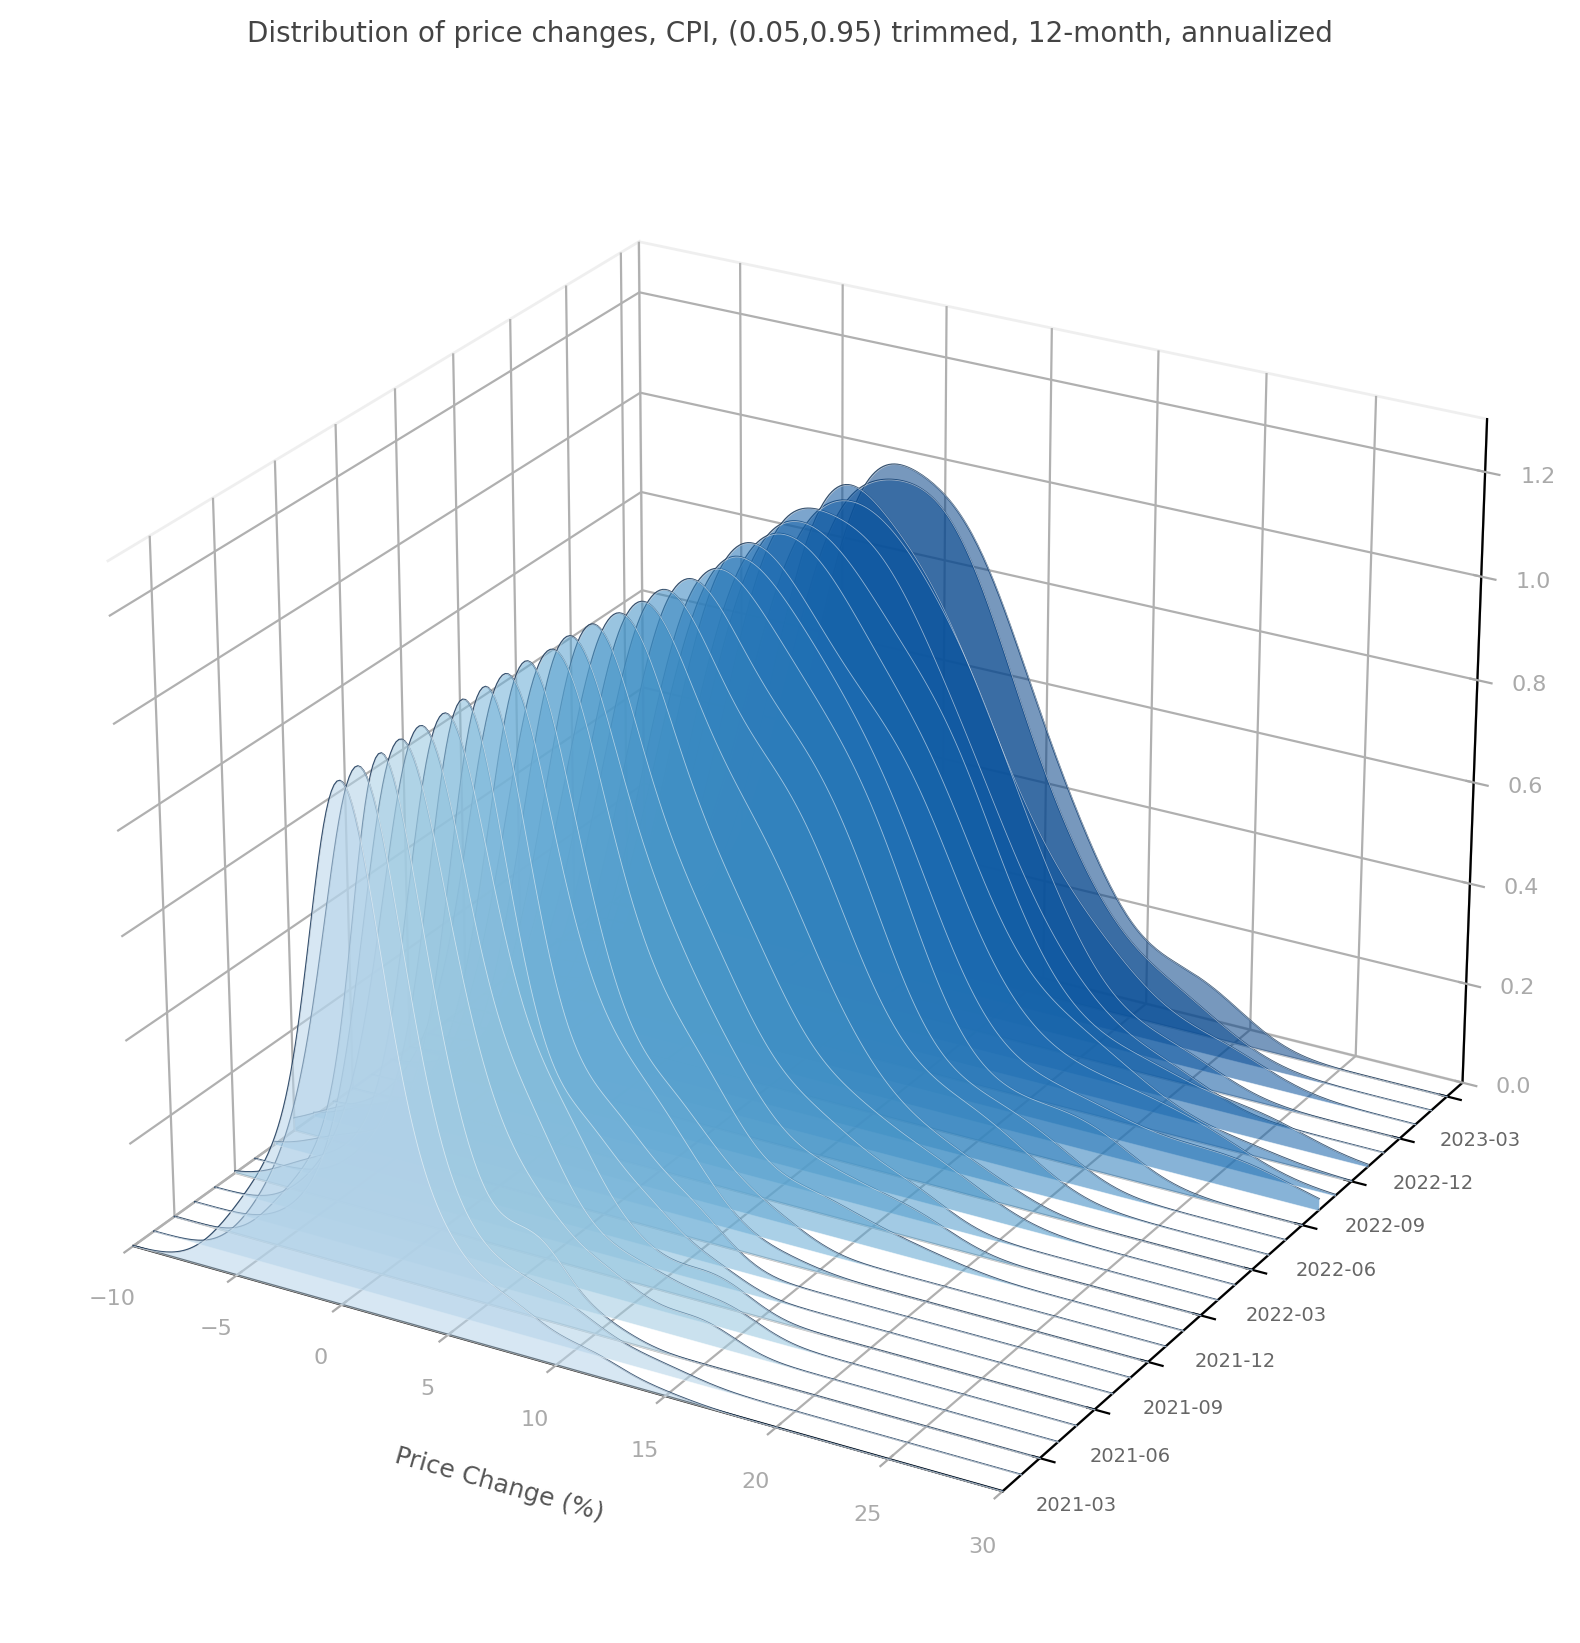

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import gaussian_kde
import matplotlib.cm as cm

type_inflation = "CPI"
lags = 12
qrange = [0.05, 0.95]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())

# 분기별만 레이블 표시할 날짜
quarter_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]

x_grid = np.linspace(-10, 30, 300)

fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# colormap: 시간 순서에 따라 색상 부여
cmap = cm.Blues
n = len(all_dates)

verts_list = []
colors_list = []

for idx, date in enumerate(all_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()  # 정규화 (높이 통일)

    # 폴리곤 꼭짓점: 아래쪽 0으로 닫기
    verts = (
        [(x_grid[0], 0)]
        + list(zip(x_grid, y_kde))
        + [(x_grid[-1], 0)]
    )

    z = idx  # 시간축 (z)
    color_val = cmap(0.3 + 0.65 * idx / n)
    verts_list.append((z, verts))
    colors_list.append(color_val)

# 뒤에서 앞 순서로 그려야 앞 분포가 위에 렌더링됨
for (z, verts), color in zip(verts_list, colors_list):
    xs = [v[0] for v in verts]
    ys = [z] * len(verts)
    zs = [v[1] for v in verts]

    # 채워진 면
    poly_verts = [list(zip(xs, ys, zs))]
    poly = Poly3DCollection(poly_verts, alpha=0.55, facecolor=color, edgecolor='white', linewidth=0.3)
    ax.add_collection3d(poly)

    # 상단 선 (분포 윤곽)
    x_line = [v[0] for v in verts[1:-1]]
    y_line = [z] * len(x_line)
    z_line = [v[1] for v in verts[1:-1]]
    ax.plot(x_line, y_line, z_line, color='#1a3a5c', linewidth=0.6, alpha=0.9)

# 축 설정
ax.set_xlim([-10, 30])
ax.set_ylim([0, n])
ax.set_zlim([0, 1.3])

# y축 틱: 분기별만
quarter_indices = [all_dates.index(d) for d in quarter_dates if d in all_dates]
ax.set_yticks(quarter_indices)
ax.set_yticklabels([d for d in quarter_dates if d in all_dates], fontsize=7, color='#666666')

ax.set_xlabel('Price Change (%)', labelpad=10, color='#555555', fontsize=9)
ax.set_zlabel('Density', labelpad=10, color='#555555', fontsize=9)
ax.tick_params(axis='x', colors='#aaaaaa', labelsize=8)
ax.tick_params(axis='z', colors='#aaaaaa', labelsize=8)

# 배경 패널 연하게
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#e0e0e0')
ax.yaxis.pane.set_edgecolor('#e0e0e0')
ax.zaxis.pane.set_edgecolor('#e0e0e0')
ax.grid(color='#eeeeee', linewidth=0.4)

# (핵심) 시점 각도: 이미지와 유사하게
ax.view_init(elev=25, azim=-60)

ax.set_title(
    f"Distribution of price changes, {type_inflation}, "
    f"({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized",
    color='#444444', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

/tmp/ipython-input-276860283.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


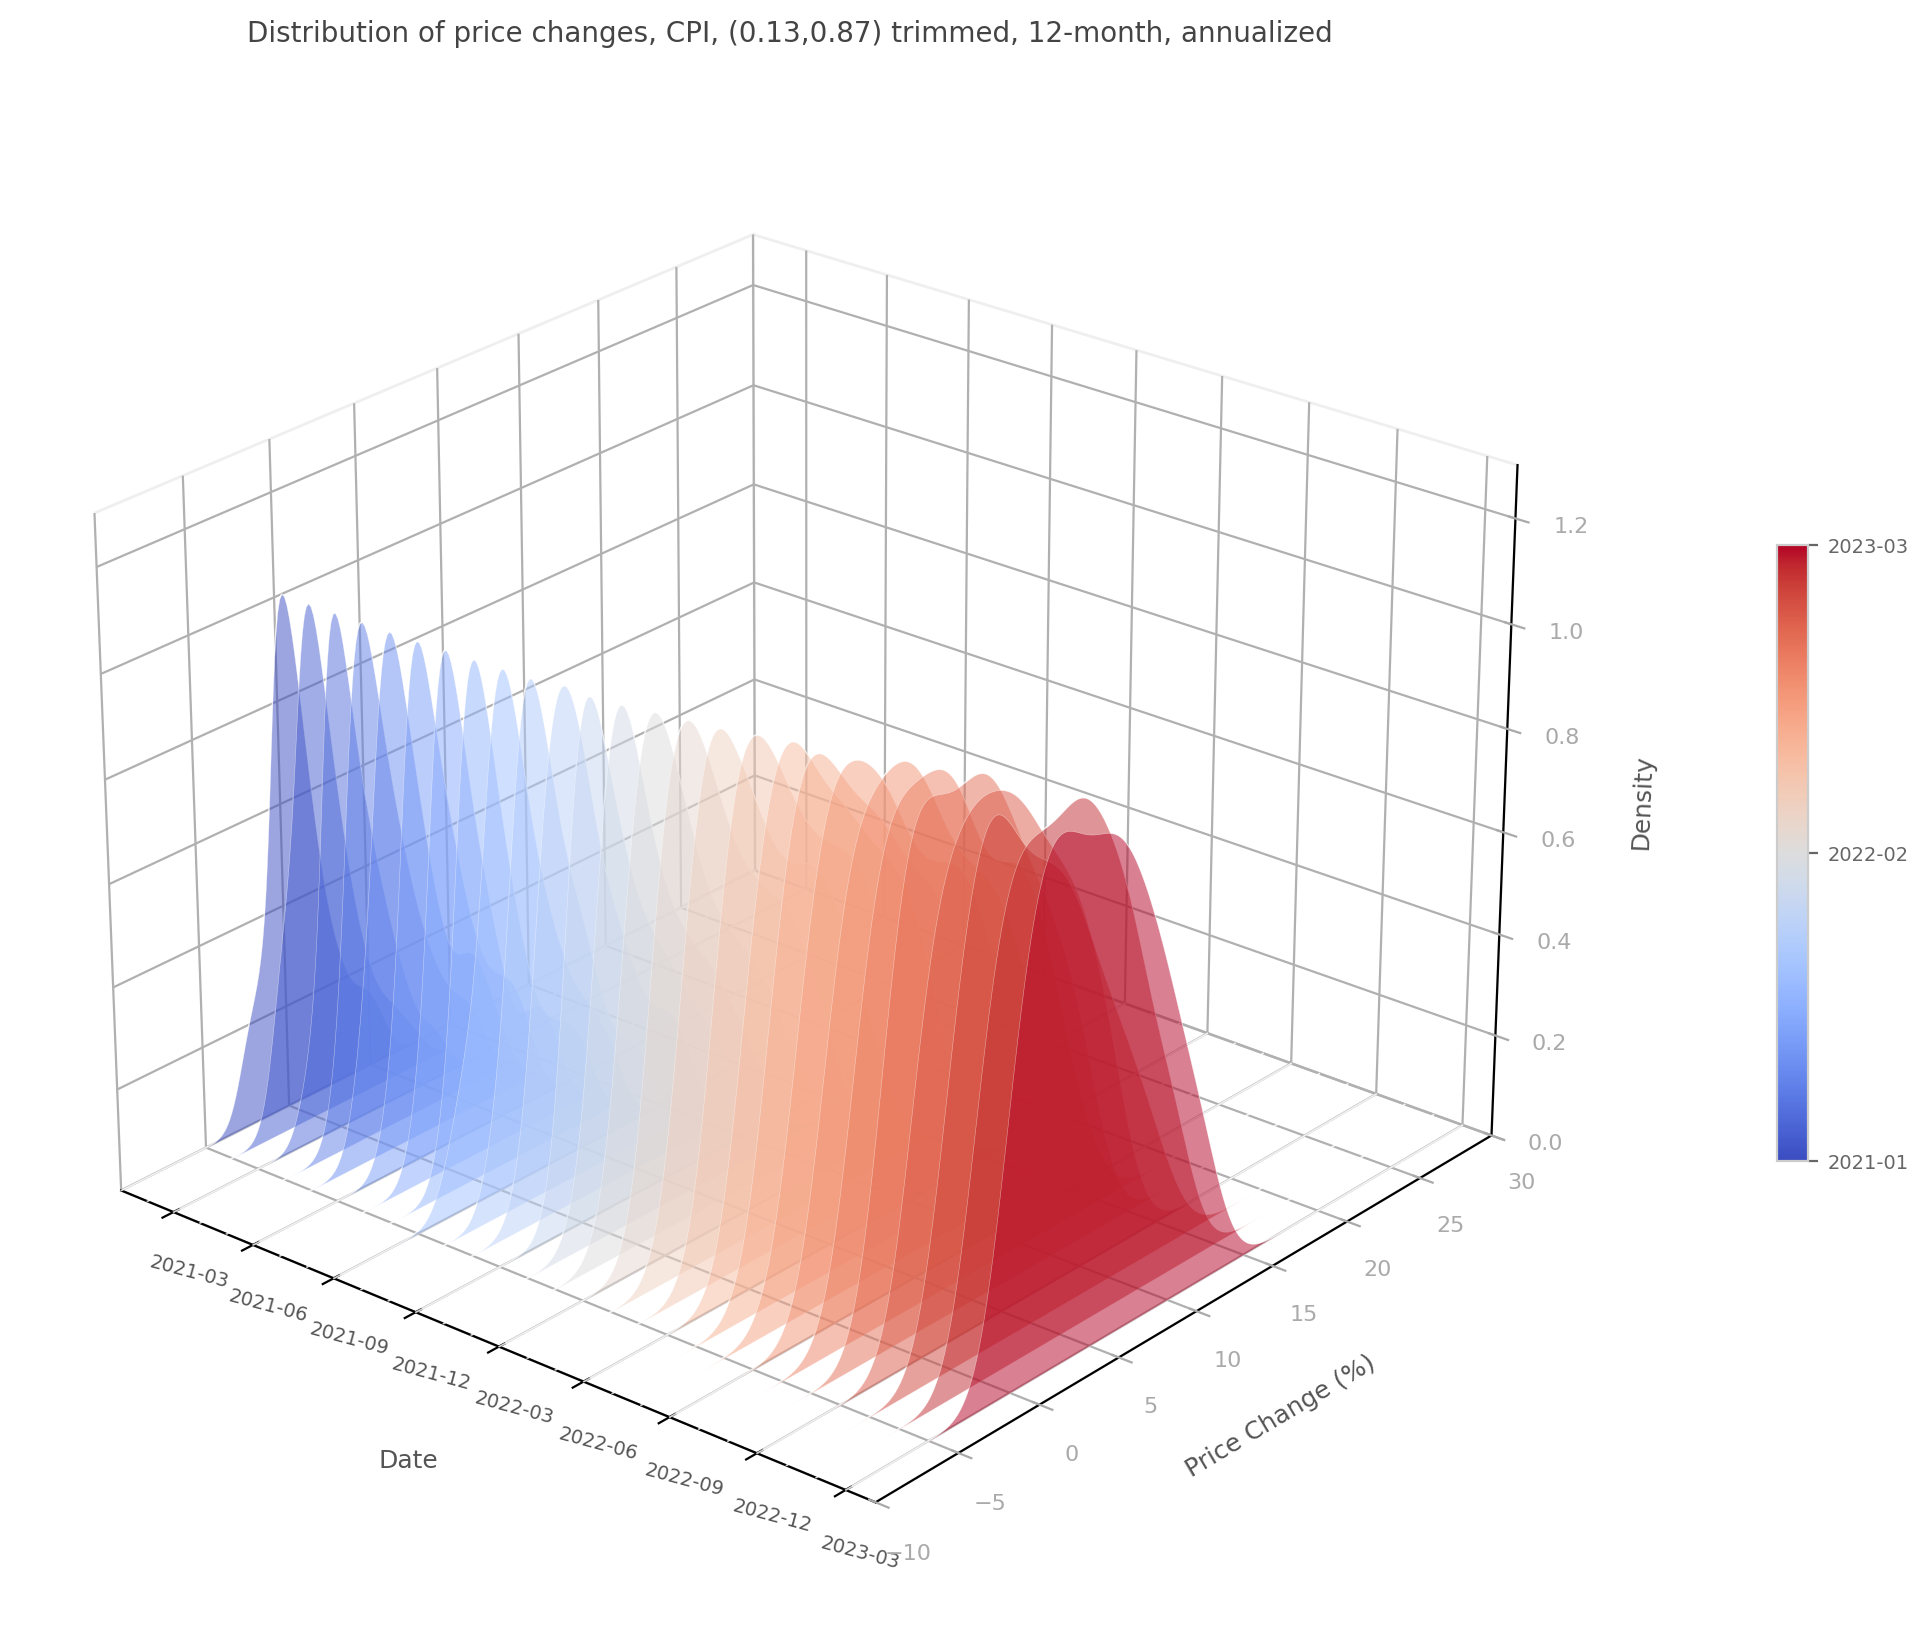

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import gaussian_kde
import matplotlib.cm as cm

type_inflation = "CPI"
lags = 12
qrange = [0.13, 0.87]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

all_dates = sorted(df_trimmed['mdate'].unique())
quarter_dates = [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]

x_grid = np.linspace(-10, 30, 300)

fig = plt.figure(figsize=(14, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

n = len(all_dates)

# 과거→최근 색상 변화: 차갑고 어두운 색 → 따뜻하고 밝은 색
cmap = cm.coolwarm   # 파란(과거) → 빨간(최근), cm.plasma / cm.turbo도 좋음

for idx, date in enumerate(all_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == date, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()

    # 축 전환: x=시간(idx), y=price change(x_grid), z=density
    x_pos = idx  # 시간축을 x로
    ys = x_grid  # price change를 y로
    zs = y_kde

    color = cmap(idx / (n - 1))  # 과거=0(파랑) → 최근=1(빨강)

    # 폴리곤 (아래 y=0으로 닫기)
    verts_x = [x_pos] * (len(ys) + 2)
    verts_y = [ys[0]] + list(ys) + [ys[-1]]
    verts_z = [0] + list(zs) + [0]

    poly_verts = [list(zip(verts_x, verts_y, verts_z))]
    poly = Poly3DCollection(poly_verts, alpha=0.5,
                            facecolor=color, edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)

    # 상단 윤곽선
    ax.plot([x_pos] * len(ys), ys, zs,
            color='white', linewidth=0.5, alpha=0.8)

# 축 범위
ax.set_xlim([0, n])
ax.set_ylim([-10, 30])
ax.set_zlim([0, 1.3])

# x축 틱: 분기별 날짜
quarter_indices = [all_dates.index(d) for d in quarter_dates if d in all_dates]
ax.set_xticks(quarter_indices)
ax.set_xticklabels(
    [d for d in quarter_dates if d in all_dates],
    fontsize=7, color='#555555', rotation=-15, ha='left'
)

# 축 레이블
ax.set_xlabel('Date', labelpad=12, color='#555555', fontsize=9)
ax.set_ylabel('Price Change (%)', labelpad=10, color='#555555', fontsize=9)
ax.set_zlabel('Density', labelpad=8, color='#555555', fontsize=9)

ax.tick_params(axis='y', colors='#aaaaaa', labelsize=8)
ax.tick_params(axis='z', colors='#aaaaaa', labelsize=8)

# 배경 패널
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#e0e0e0')
ax.yaxis.pane.set_edgecolor('#e0e0e0')
ax.zaxis.pane.set_edgecolor('#e0e0e0')
ax.grid(color='#eeeeee', linewidth=0.4)

# 컬러바 추가 (과거→최근)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.1, aspect=20)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([all_dates[0], all_dates[n // 2], all_dates[-1]], fontsize=7)
cbar.ax.tick_params(colors='#666666')
cbar.outline.set_edgecolor('#cccccc')

# 시점 각도
ax.view_init(elev=25, azim=-50)

ax.set_title(
    f"Distribution of price changes, {type_inflation}, "
    f"({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized",
    color='#444444', fontsize=10, pad=15
)

plt.tight_layout()
plt.show()

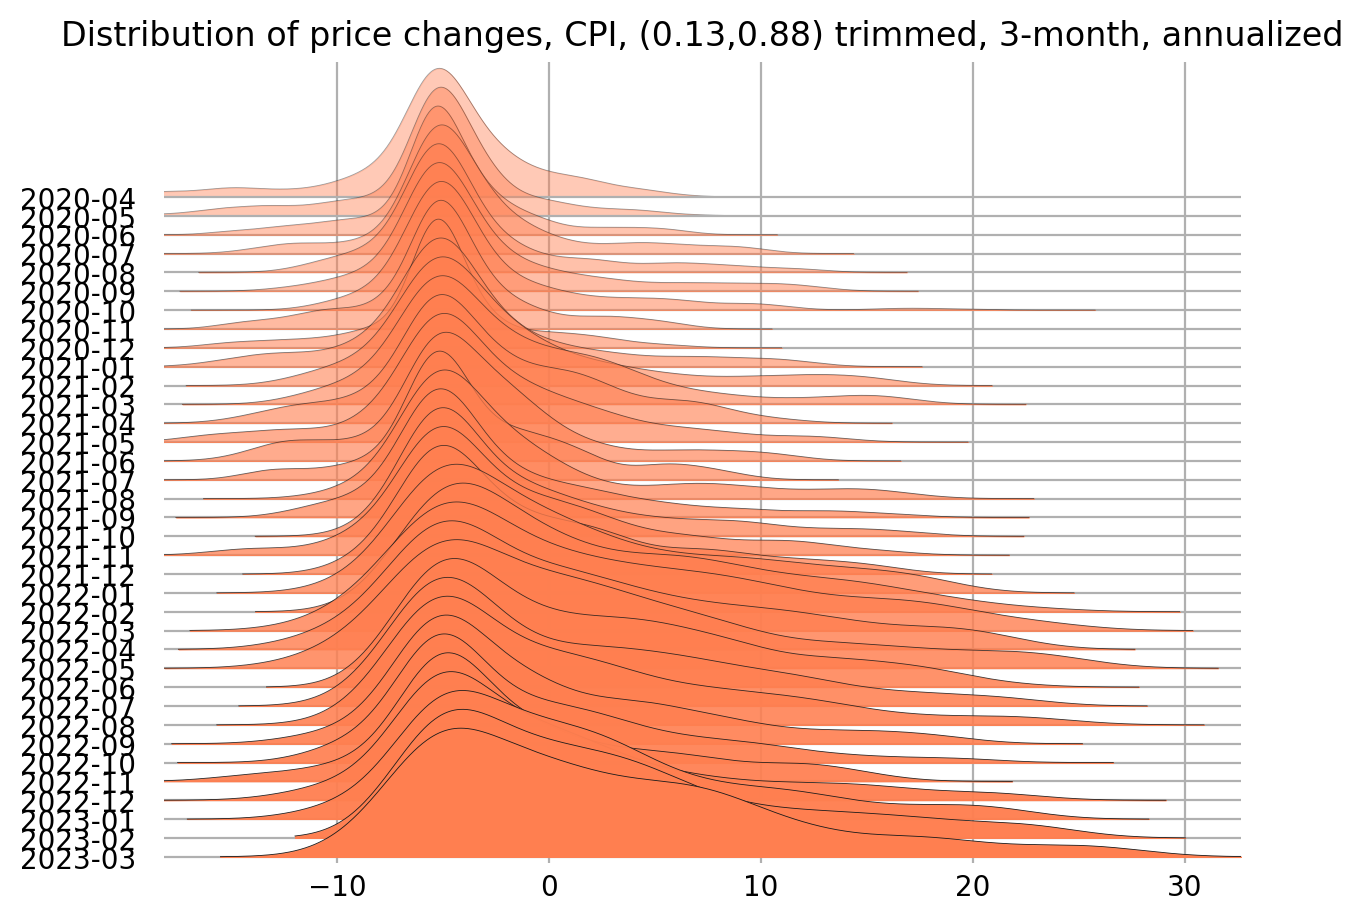

In [32]:
type_inflation = "CPI"
lags = 3
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )

for a in axes[:-1]:
    a.set_xlim([-10,30])

#save_fig('joyplot_CPI_3')
plt.show()



/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

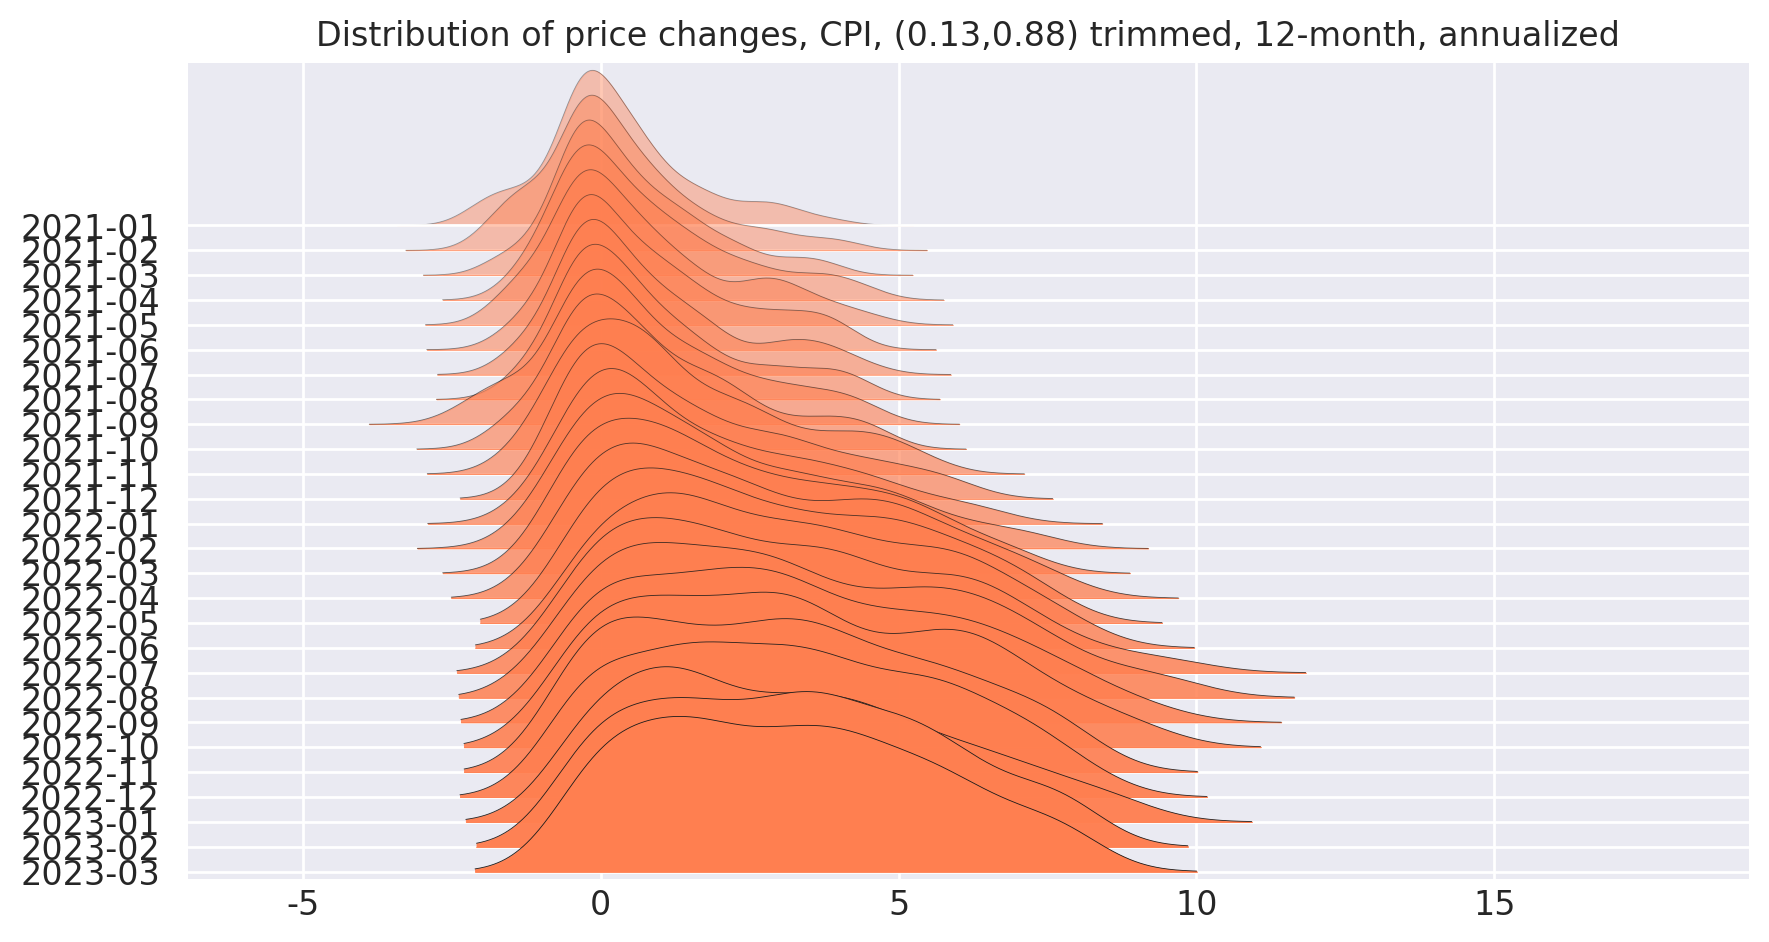

In [ ]:
type_inflation = "CPI"
lags = 12
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )

for a in axes[:-1]:
    a.set_xlim([-10,30])

plt.show()

/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

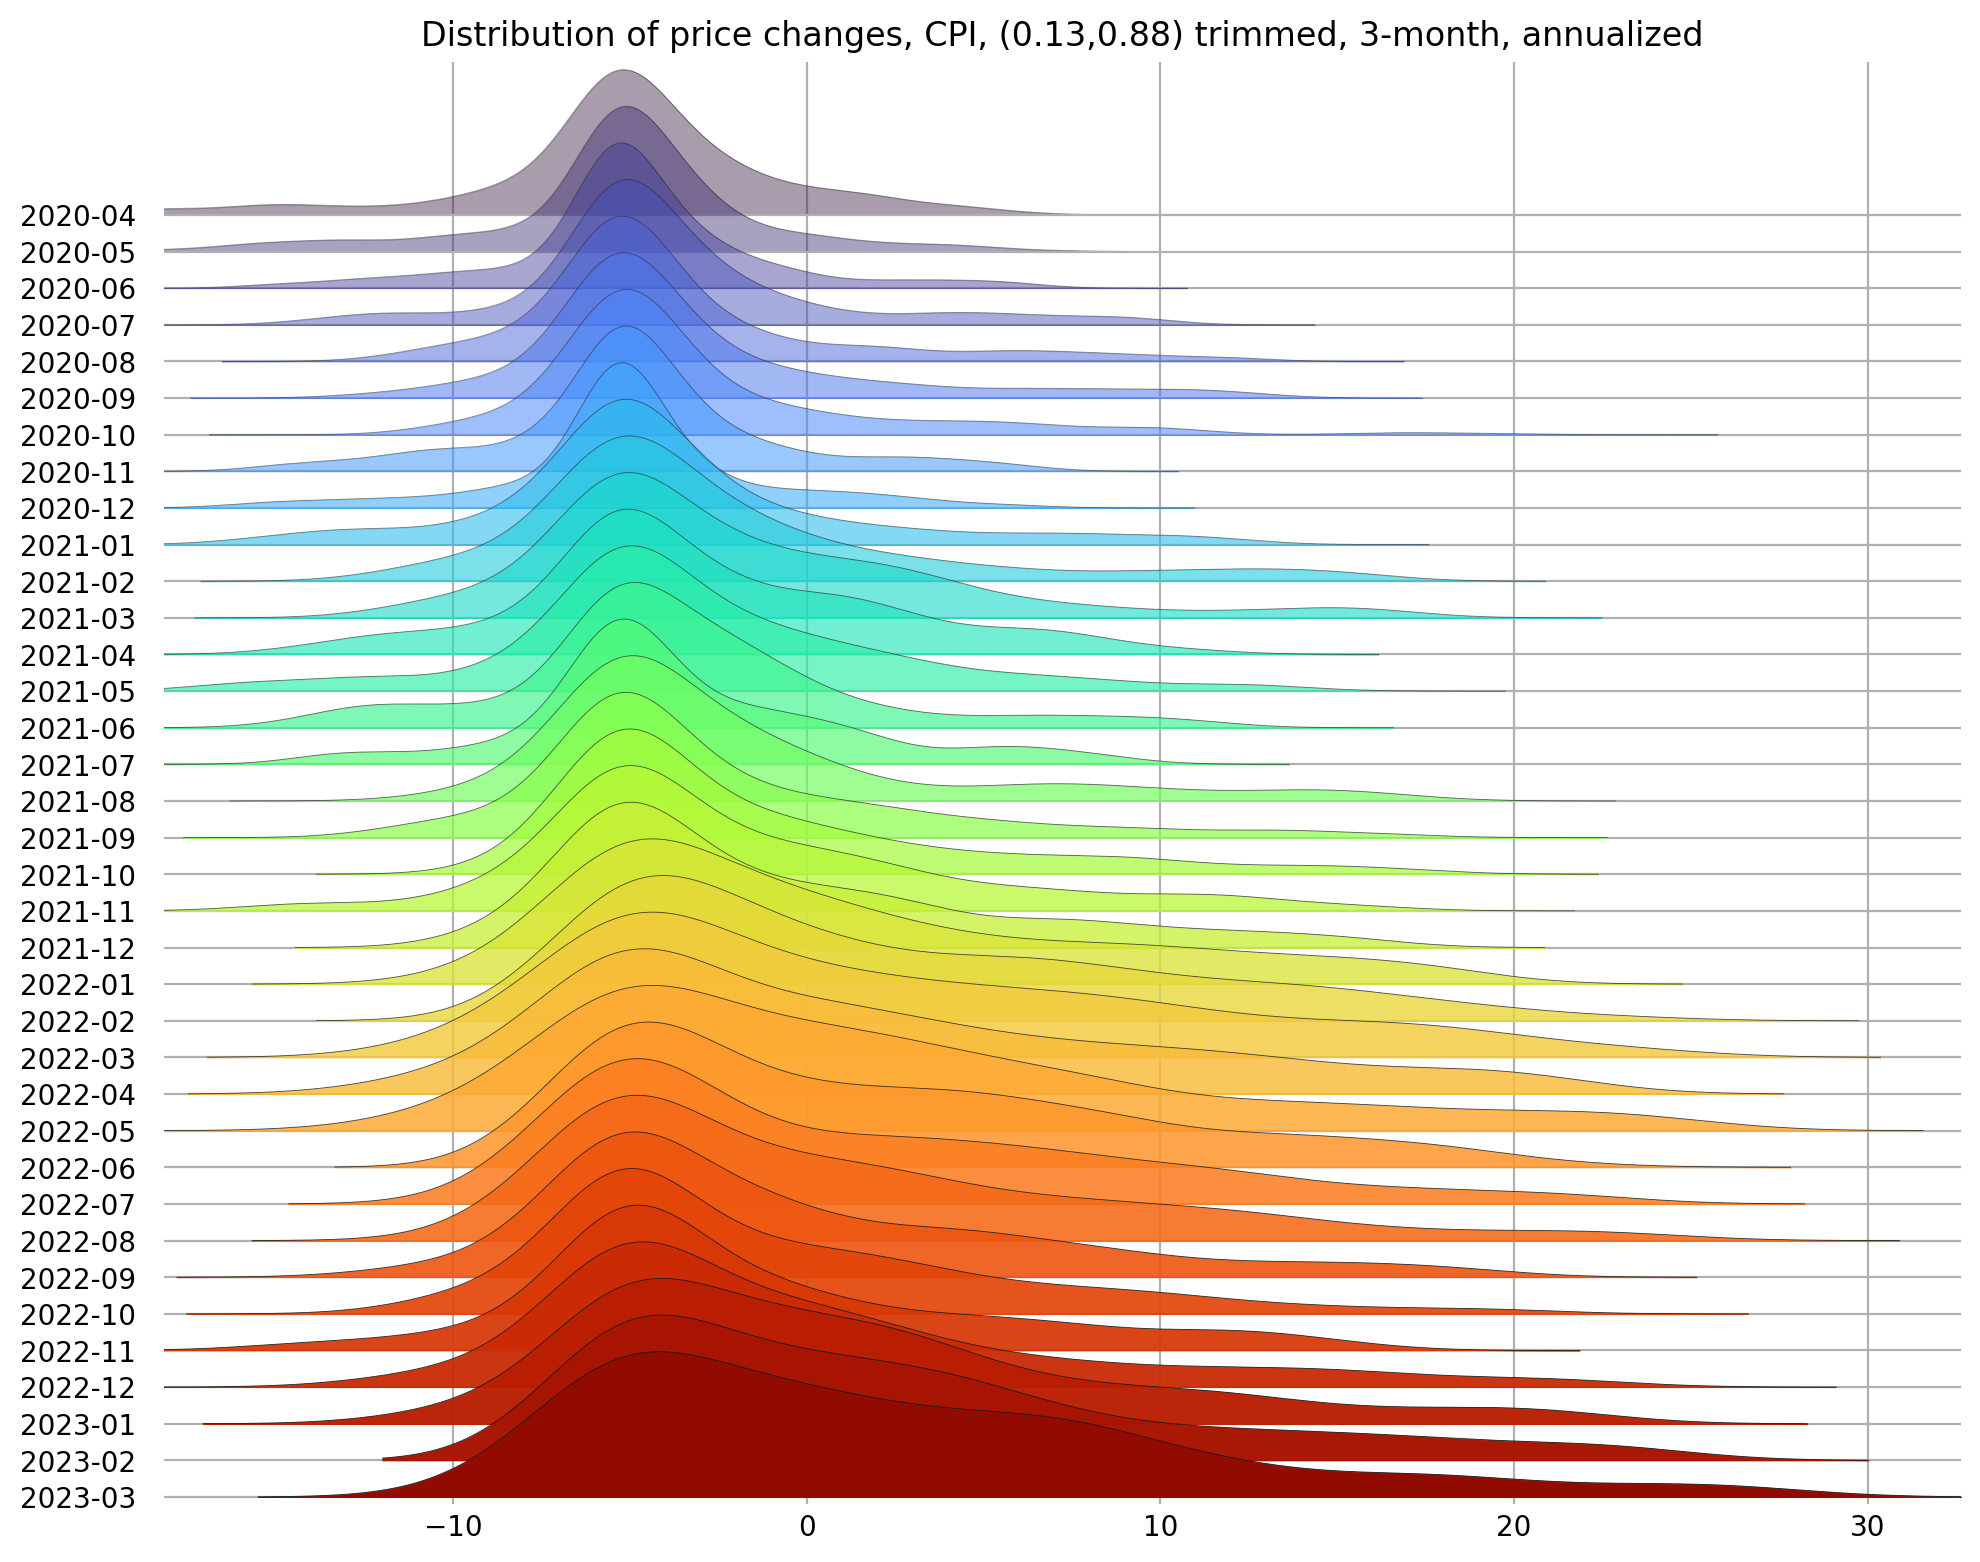

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

type_inflation = "CPI"
lags = 3
qrange = [0.13, 0.88]
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

# 배경을 흰색으로 설정
plt.style.use('default')  # 또는 plt.style.use('seaborn-white')
fig, axes = joypy.joyplot(
    df_trimmed,
    by="mdate",
    range_style='own',
    ylim='own',
    fade=True,
    linewidth=0.3,
    colormap=cm.turbo,
    grid=True,
    title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized",
    figsize=(10, 8),
    background='white'  # 배경 흰색 설정
)

# Figure의 배경색도 흰색으로 설정
fig.patch.set_facecolor('white')

for a in axes[:-1]:
    a.set_xlim([-10, 30])
    a.set_facecolor('white')  # 각 축의 배경도 흰색으로

plt.show()

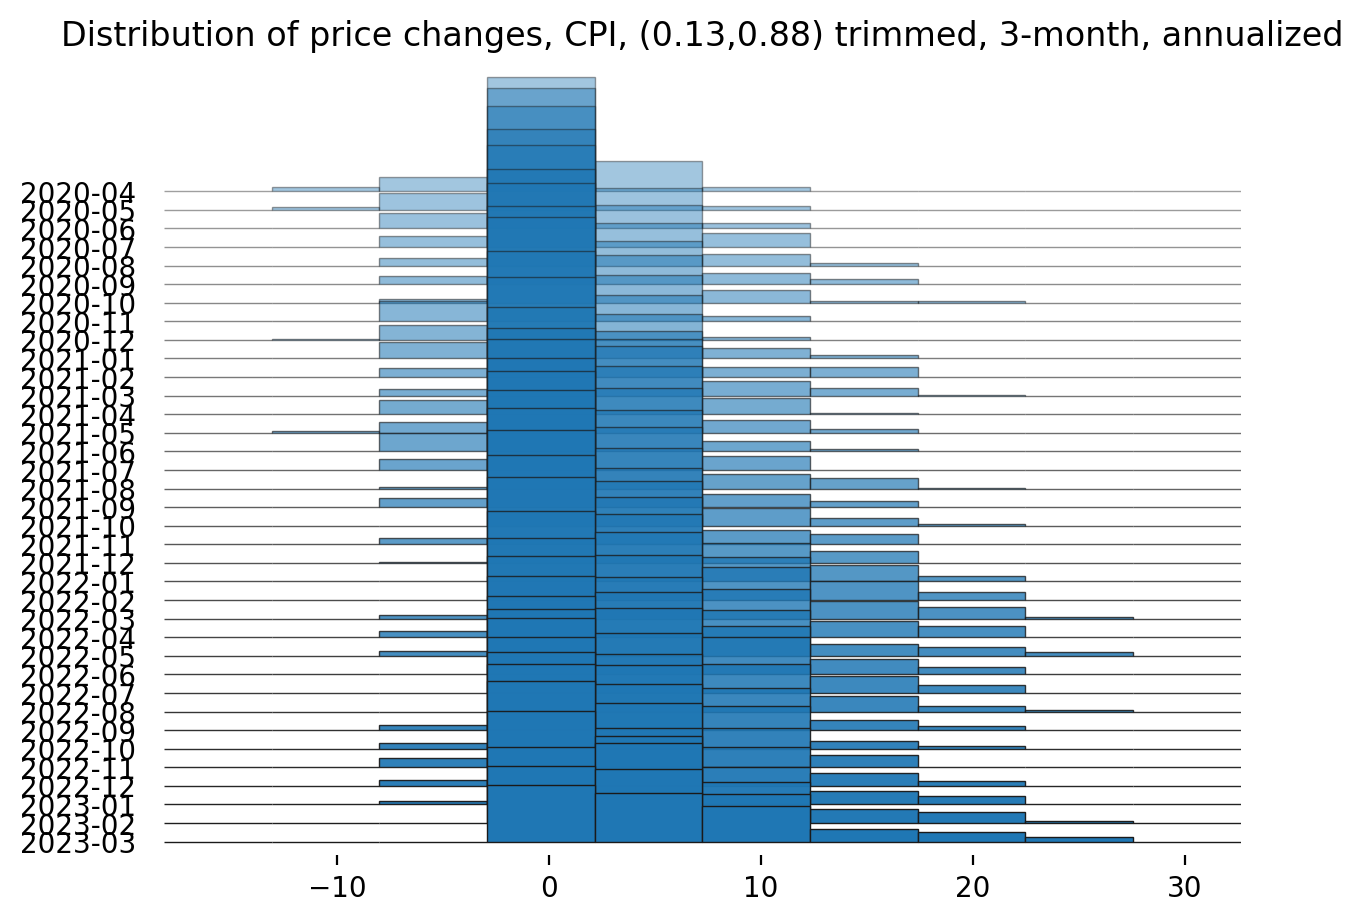

In [ ]:
fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        fade=True, linewidth=0.5, colormap=cm.autumn,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized",
                        hist=True
                        )



/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

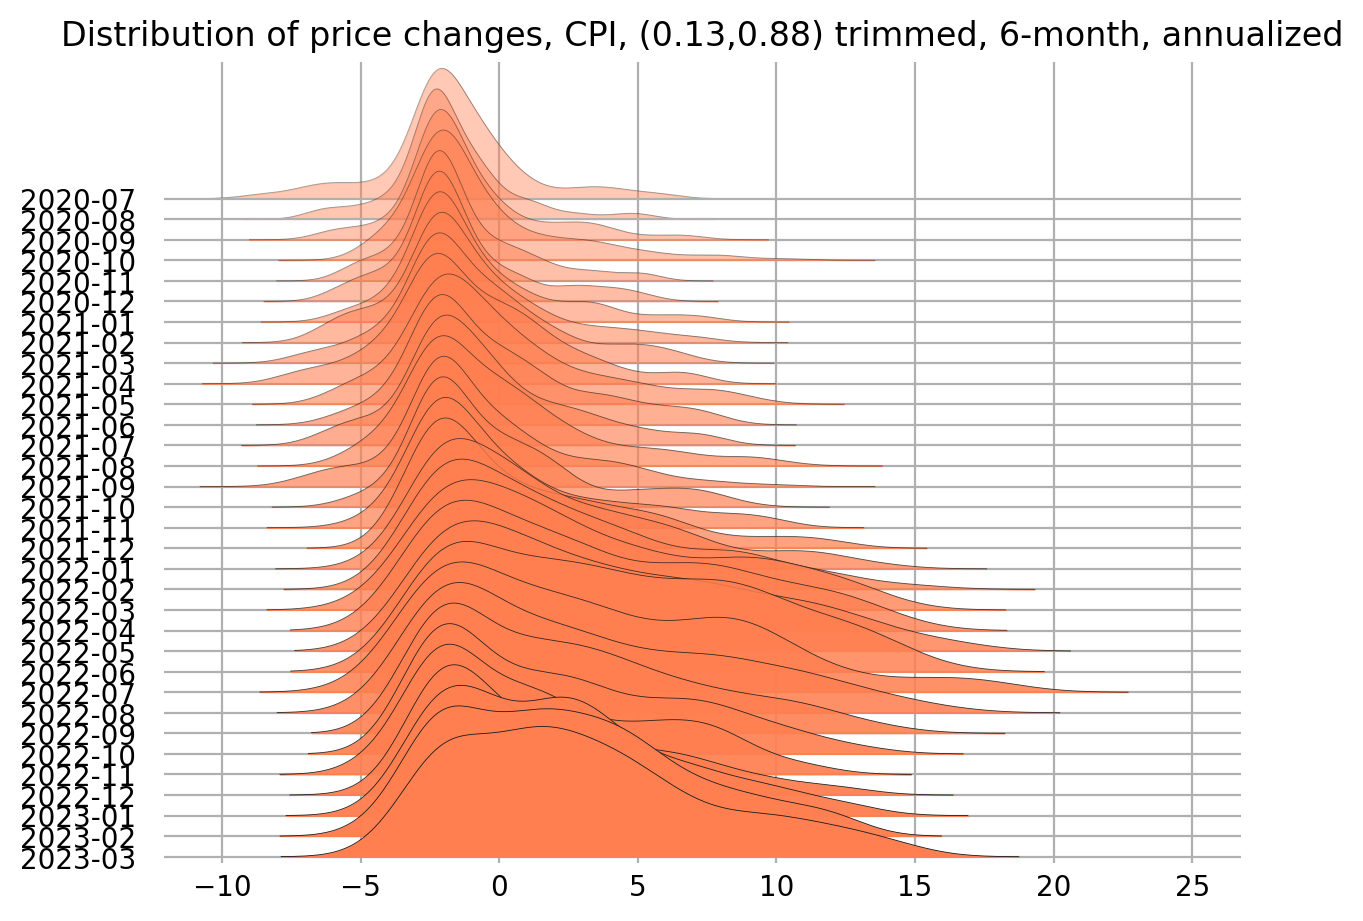

In [ ]:
type_inflation = "CPI"
lags = 6
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )

for a in axes[:-1]:
    a.set_xlim([-10,30])

plt.show()


/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

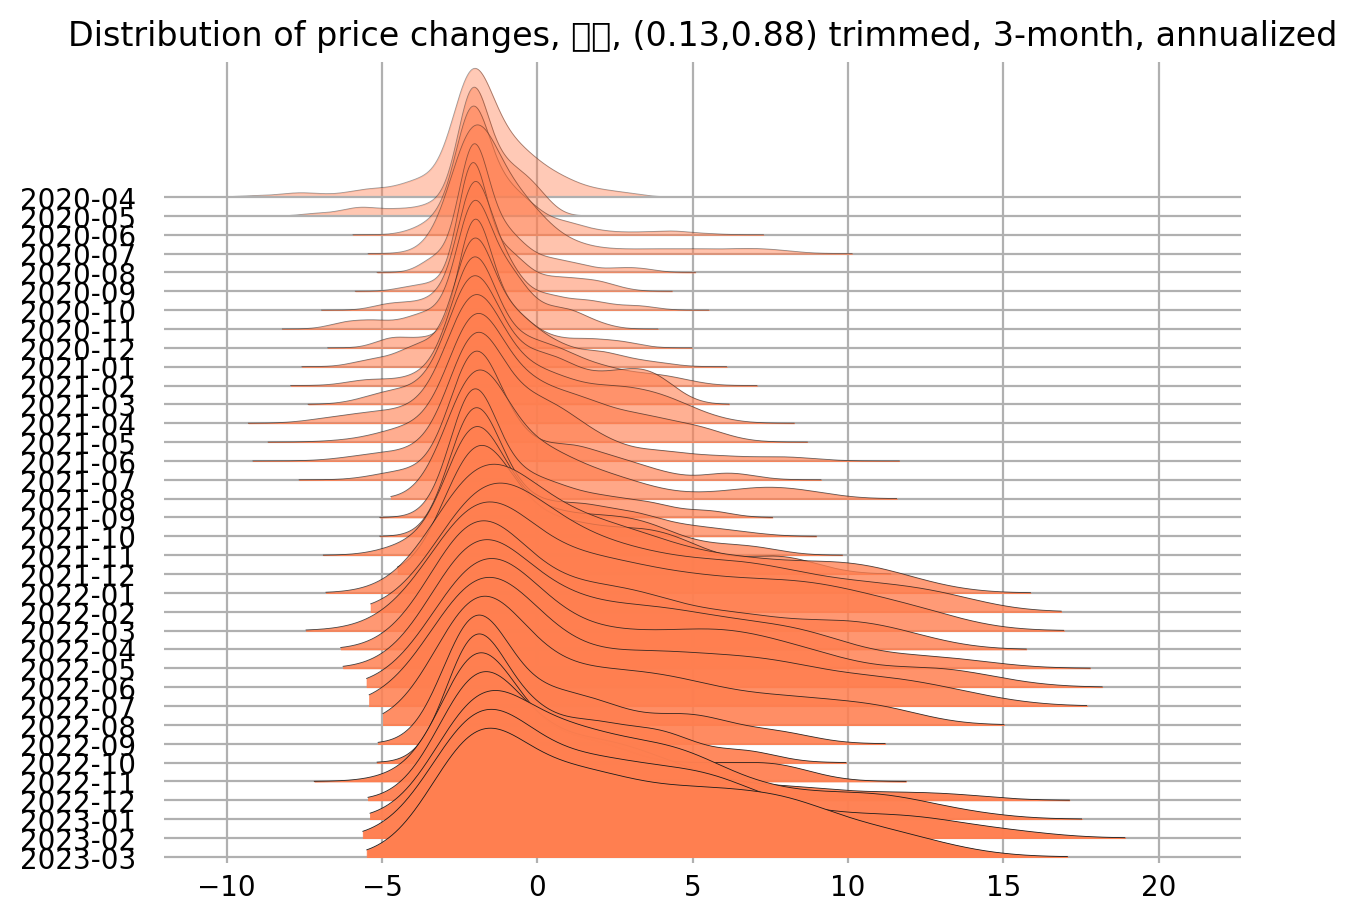

In [ ]:
type_inflation = "근원"
lags = 3
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )

for a in axes[:-1]:
    a.set_xlim([-10,25])

plt.show()


In [ ]:
df_trimmed.describe()

,trimmed values
count,"8,397.000"
mean,2.319
std,3.506
min,-7.063
25%,0.000
50%,0.830
75%,3.671
max,17.694


/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

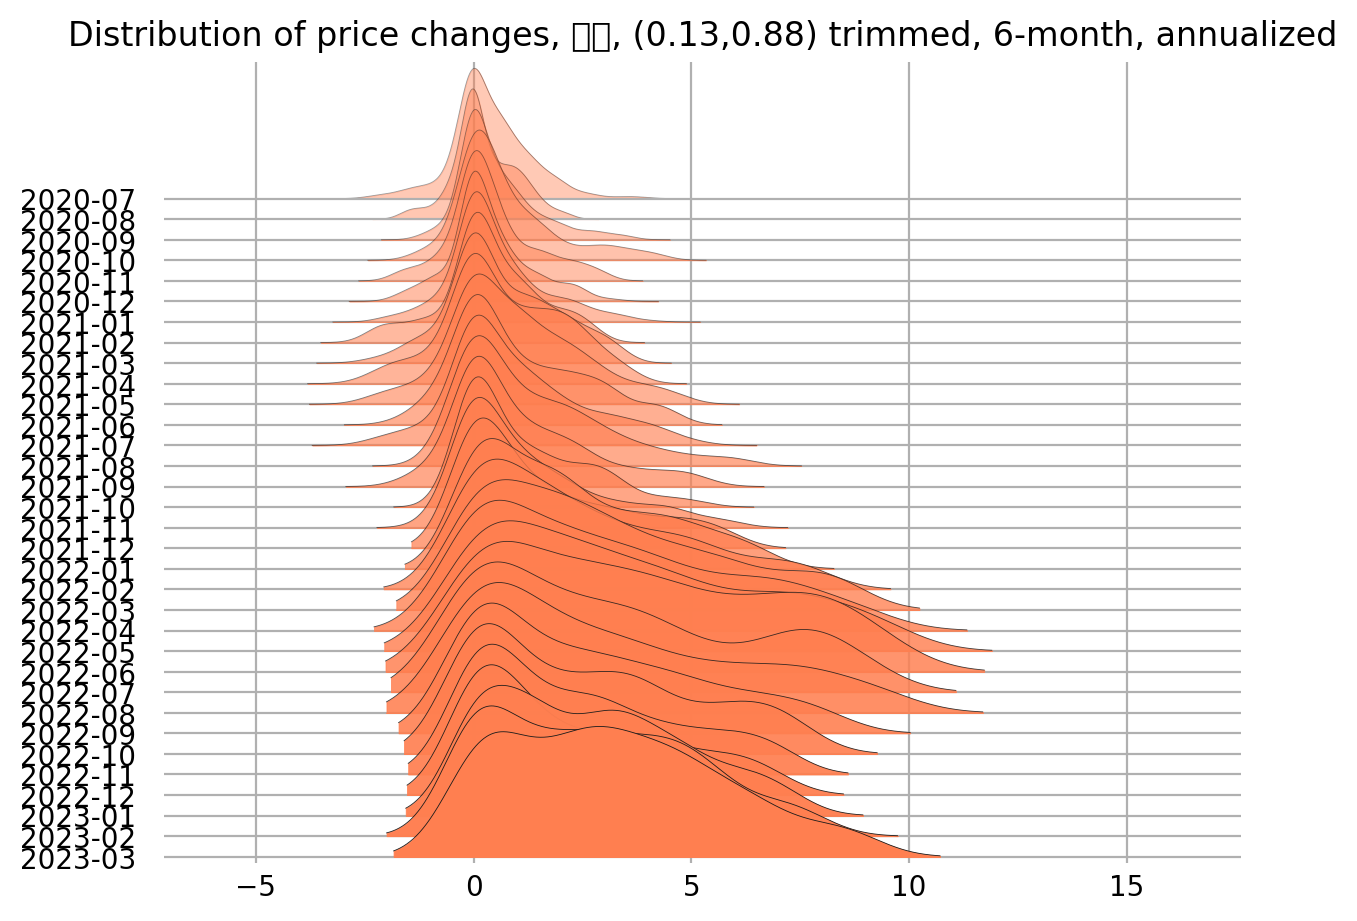

In [ ]:
type_inflation = "근원"
lags = 6
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )
for a in axes[:-1]:
    a.set_xlim([-10,25])

plt.show()

In [ ]:
df_trimmed.describe()

,trimmed values
count,"7,680.000"
mean,2.495
std,3.145
min,-3.575
25%,0.000
50%,1.415
75%,4.019
max,14.085


/tmp/ipython-input-1237287119.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/ipython-input-1237287119.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_trim['mdate'].replace('NaN',df_trim.columns[0],inplace=True)
/tmp/i

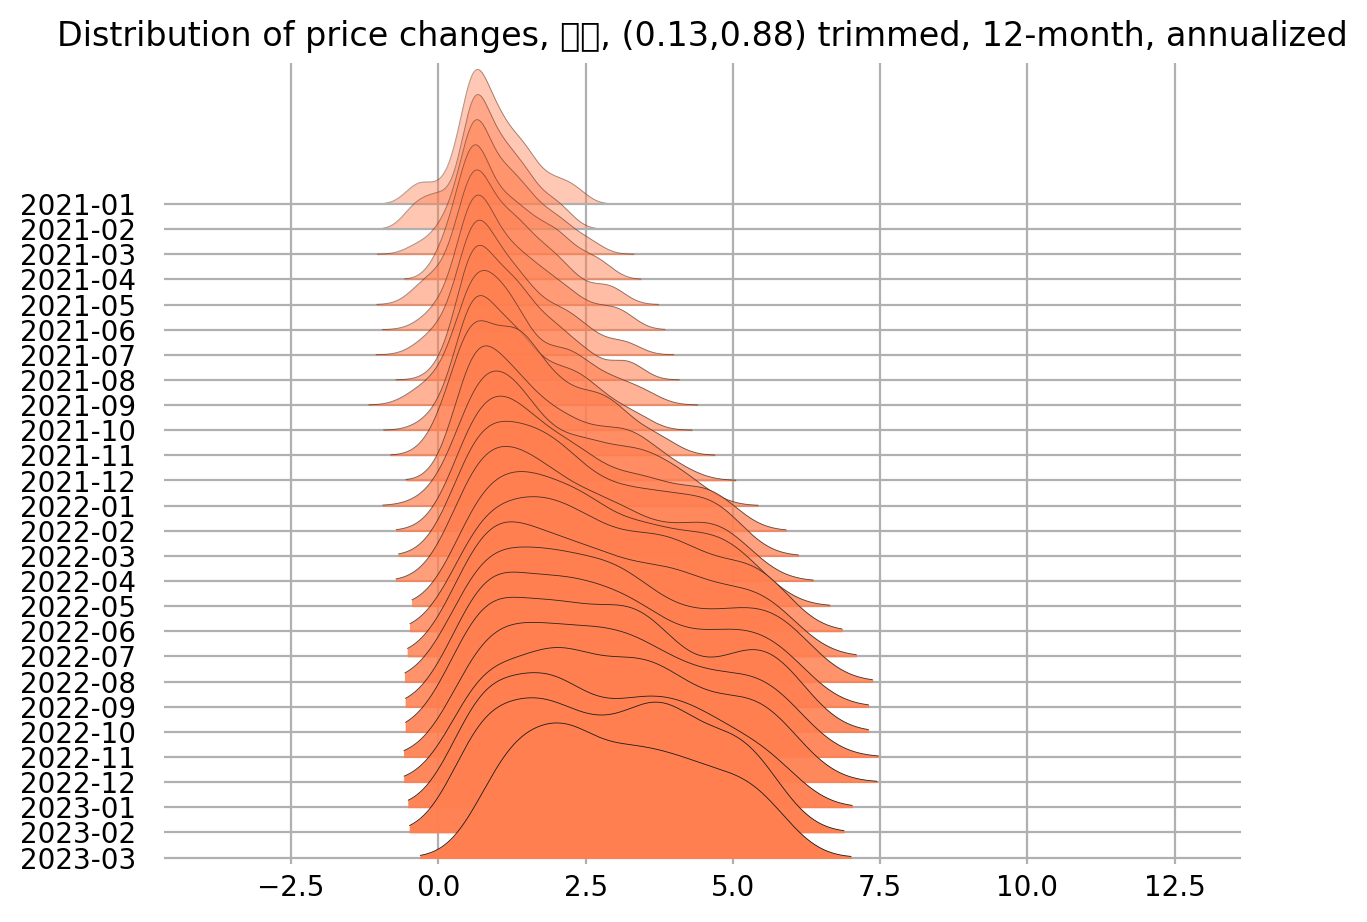

In [ ]:
type_inflation = "근원"
lags = 12
qrange = [0.13,0.88]

df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

fig, axes = joypy.joyplot(df_trimmed, by="mdate", range_style='own',
                        #overlap=2,
                        ylim='own',
                        fade=True,
                        linewidth=0.3,
                        color='coral',
                        #colormap=cm.summer_r,
                        grid=True,
                        #alpha=0.7,
                        title=f"Distribution of price changes, {type_inflation}, ({qrange[0]},{qrange[1]}) trimmed, {lags}-month, annualized"
                        )

for a in axes[:-1]:
    a.set_xlim([-10,25])

plt.show()
